# Norman 2019 — Main Figure

Runs SHERLOCK (`l0_lambda=25, rank=6, synergy=True`) `N_RUNS` times on the held-out Norman split,
selects the best model by held-out combo ATE, and assembles a four-panel journal figure:

| Panel | Content |
|---|---|
| **(a)** | Counterfactual ATE across N runs — reproducibility & OOD generalisation |
| **(b)** | Single-perturbation latent UMAP (best model) |
| **(c)** | Parent-coefficient scatter (c₁ vs c₂) coloured by Norman GT class |
| **(d)** | GI classification AUC-ROC per class — SHERLOCK vs GEARS |

The notebook saves every intermediate result to `results/norman_figure/` and the final
composite figure to `results/norman_figure/main_figure.pdf`.

In [1]:
import os, sys, math, random, textwrap
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr, bootstrap
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler

import scanpy as sc
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import torch

sys.path.append('../../..')
import sherlock as slk
from sherlock.tools._models import classify_gi

# ── Journal figure style ────────────────────────────────────────────────
RC = {
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':             8,
    'axes.labelsize':        8,
    'axes.titlesize':        9,
    'xtick.labelsize':       7,
    'ytick.labelsize':       7,
    'legend.fontsize':       6,
    'legend.title_fontsize': 7,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.linewidth':        0.75,
    'xtick.major.width':     0.75,
    'ytick.major.width':     0.75,
    'xtick.major.size':      3,
    'ytick.major.size':      3,
    'figure.dpi':            150,
    'savefig.dpi':           300,
    'pdf.fonttype':          42,
    'ps.fonttype':           42,
    'svg.fonttype': 'none',
}
mpl.rcParams.update(RC)

PPI = 96  # Figma/CSS px-per-inch — matches how pt-labeled SVGs get imported

# ── Colour palette ─────────────────────────────────────────────────────
CLR_SHERLOCK    = '#2166ac'
CLR_GEARS       = '#d73027'

# Keys match the exact strings in genetic_interactions.csv
PALETTE_GI = {
    'approximately additive':         '#4DAF4A',  # green
    'epistasis':                      '#FF7F00',  # orange
    'neomorphic':                     '#984EA3',  # purple
    'potentiation':                   '#F781BF',  # pink
    'redundant':                      '#A65628',  # brown
    'suppression':                    '#E41A1C',  # red
    'synergy (dissimilar phenotype)': '#377EB8',  # blue
    'synergy (similar phenotype)':    '#6BAED6',  # light blue
}

def _add_umap_axis_indicator(ax, x_label='UMAP1', y_label='UMAP2', length=0.15,
                              lw=1.0, color='0.15', fontsize=None):
    """Small L-shaped corner axis indicator (scanpy/Seurat style) — two short
    arrows from the bottom-left corner instead of full tick-labelled spines,
    used on UMAP panels where absolute coordinates are meaningless."""
    if fontsize is None:
        fontsize = mpl.rcParams['axes.labelsize']
    ax.annotate('', xy=(length, 0), xytext=(0, 0),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='-|>', color=color, lw=lw,
                                 shrinkA=0, shrinkB=0))
    ax.annotate('', xy=(0, length), xytext=(0, 0),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='-|>', color=color, lw=lw,
                                 shrinkA=0, shrinkB=0))
    ax.text(length / 2, -0.03, x_label, transform=ax.transAxes, fontsize=fontsize,
            ha='center', va='top', color=color)
    ax.text(-0.03, length / 2, y_label, transform=ax.transAxes, fontsize=fontsize,
            ha='right', va='center', color=color, rotation=90)


# ── Constants ──────────────────────────────────────────────────────────
N_RUNS    = 5
SEED_BASE = 0
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT_DIR   = Path('./results/norman_figure')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device: {DEVICE}  |  N_RUNS: {N_RUNS}  |  Output: {OUT_DIR}')

Device: cuda  |  N_RUNS: 5  |  Output: results/norman_figure


## 1. Load and preprocess Norman 2019

In [2]:
data = sc.read_h5ad('../Norman_2019.h5ad')
data.X = data.layers['counts'].copy()

slk.pp.slk_prepare_data(
    data,
    pert_key='perturbation_name',
    ntc_label='control',
    treatment_key=None,
    inplace=True,
)

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

all_perts    = data.obs[p_key].unique()
single_perts = [p for p in all_perts if '+' not in str(p) and p != NTC]
combo_perts  = [p for p in all_perts if '+' in str(p)]
print(f'Cells: {data.n_obs}  |  Genes: {data.n_vars}')
print(f'Single perts: {len(single_perts)}  |  Combo perts: {len(combo_perts)}')

Cells: 111255  |  Genes: 19018
Single perts: 105  |  Combo perts: 131


In [3]:
# Gene filtering: keep genes with mean count > 0.5 UMI or that are pert targets
pert_genes = set()
for p in all_perts:
    if p != NTC:
        for g in str(p).split('+'):
            pert_genes.add(g.strip())

mean_expr = np.array(data.X.mean(axis=0)).flatten()
expr_mask = mean_expr > 0.5
pert_mask = data.var_names.isin(pert_genes)
keep_mask = expr_mask | pert_mask
data = data[:, keep_mask].copy()

print(f'Kept {data.n_vars} genes  '
      f'({expr_mask[keep_mask].sum()} expr + '
      f'{(pert_mask[keep_mask] & ~expr_mask[keep_mask]).sum()} pert-only)')

Kept 3270 genes  (3190 expr + 80 pert-only)


In [4]:
# Observed treatment effects (log2-CPM vs NTC baseline)
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
te = data.uns['treat_effect']
print(f'treat_effect: {te.n_obs} perturbations × {te.n_vars} genes')

100%|████████████████████████████████████████████████████████████████████████| 236/236 [00:07<00:00, 32.62it/s]

treat_effect: 236 perturbations × 3270 genes


## 2. Train/val split — 20% of each Norman GT class held out

In [5]:
def canon_pair(s):
    s = str(s)
    if '+' not in s:
        return s
    a, b = s.split('+', 1)
    return '+'.join(sorted([a.strip(), b.strip()]))

random.seed(42)
gi_labels = pd.read_csv('./genetic_interactions.csv')
gi_labels['combination'] = gi_labels['combination'].apply(canon_pair)
gi_labels['genetic_interaction'] = gi_labels['genetic_interaction'].str.strip()

val_combos = set()
for cls, grp in gi_labels.groupby('genetic_interaction'):
    n_val = math.ceil(0.2 * len(grp))
    val_combos.update(random.sample(list(grp['combination']), n_val))

val_mask   = data.obs[p_key].apply(lambda p: ('+' in str(p)) and (canon_pair(p) in val_combos))
data_train = data[~val_mask].copy()

print(f'Total cells: {data.n_obs}  |  Training: {data_train.n_obs}')
print(f'GT pairs: {len(gi_labels)}  |  Held-out val combos: {len(val_combos)}')

Total cells: 111255  |  Training: 104626
GT pairs: 88  |  Held-out val combos: 22


## 3. Multi-run training

Trains SHERLOCK `N_RUNS` times with identical settings. After each run, computes ATE on
the full data (including held-out combos). The best run by held-out combo ATE is used for
UMAP, synergy analysis, and GI classification.

In [6]:
def _ate_r(pred_df, obs_df, idx):
    idx = [p for p in idx if p in pred_df.index and p in obs_df.index]
    if len(idx) < 2:
        return float('nan')
    x = pred_df.loc[idx].values.ravel()
    y = obs_df.loc[idx].values.ravel()
    v = np.isfinite(x) & np.isfinite(y)
    return float(pearsonr(x[v], y[v])[0]) if v.sum() > 2 else float('nan')


def _effect_size_r(pred_df, obs_df):
    common = pred_df.index.intersection(obs_df.index)
    if len(common) < 3:
        return float('nan')
    p_norms = pred_df.loc[common].apply(np.linalg.norm, axis=1).values
    o_norms = obs_df.loc[common].apply(np.linalg.norm, axis=1).values
    v = np.isfinite(p_norms) & np.isfinite(o_norms)
    return float(pearsonr(p_norms[v], o_norms[v])[0]) if v.sum() > 2 else float('nan')


def _w_coact_matrix(W, threshold=0.5):
    """(P, P) cosine-normalized perturbation co-activation matrix. Invariant
    to permutation of the K gate dimensions, so it can be compared directly
    across independently trained runs (unlike the raw W)."""
    W_bin = (W > threshold).astype(float)
    dot   = W_bin @ W_bin.T
    norms = np.sqrt(np.diag(dot))
    denom = np.outer(norms, norms) + 1e-8
    return dot / denom


def _flat_triu(M):
    idx = np.triu_indices(M.shape[0], k=1)
    return M[idx]


def _loo_spearman_df(mats_by_run, metric_name):
    """Spearman r between each run's (P, P) matrix and the elementwise mean of
    every OTHER run's matrix (leave-one-out) — one row per run (n total).
    Unlike the C(n, 2) all-pairs comparisons, these n points each depend on a
    distinct held-out run, so they behave like an i.i.d. sample for
    bootstrapping instead of n(n-1)/2 non-independent pairs drawn from only
    n underlying runs."""
    rows = []
    keys = sorted(mats_by_run)
    for k in keys:
        others = [mats_by_run[j] for j in keys if j != k]
        if not others:
            continue
        mean_other = np.mean(others, axis=0)
        vi, vj = _flat_triu(mats_by_run[k]), _flat_triu(mean_other)
        valid  = np.isfinite(vi) & np.isfinite(vj)
        r = float(spearmanr(vi[valid], vj[valid])[0]) if valid.sum() > 2 else float('nan')
        rows.append({'metric': metric_name, 'run': k, 'r': r})
    return pd.DataFrame(rows)


def _compute_ate_metrics(model, data, val_combos):
    """Compute all ATE breakdown metrics for a model on full data."""
    ate  = model.predict_counterfactual_effects(
        data, n_centroids=25, observed_effect=data.uns['treat_effect'], approximate=False
    )
    pred = ate['predicted_df']
    obs  = ate['observed_df']
    singles = [p for p in pred.index if '+' not in str(p)]
    combos  = [p for p in pred.index if '+' in str(p) and canon_pair(p) not in val_combos]
    held    = [p for p in pred.index if canon_pair(p) in val_combos]
    return ate, pred, obs, {
        'ate_all':    ate['corr'],
        'ate_single': _ate_r(pred, obs, singles),
        'ate_combo':  _ate_r(pred, obs, combos),
        'ate_held':   _ate_r(pred, obs, held),
    }


def _cache_fresh(cache_path, *source_paths):
    """True if cache_path exists and is at least as new as every path in
    source_paths (files, or directories checked recursively). Retraining a
    model should invalidate every cache derived from it; comparing mtimes
    lets that happen automatically instead of a cache silently outliving the
    checkpoint(s) it was computed from."""
    cache_path = Path(cache_path)
    if not cache_path.exists():
        return False
    cache_mtime = cache_path.stat().st_mtime
    for src in source_paths:
        src = Path(src)
        if not src.exists():
            return False
        if src.is_dir():
            sub_paths = list(src.rglob('*'))
            if not sub_paths:
                continue
            src_mtime = max(p.stat().st_mtime for p in sub_paths)
        else:
            src_mtime = src.stat().st_mtime
        if src_mtime > cache_mtime:
            return False
    return True


# ── Paths ──────────────────────────────────────────────────────────────
MODELS_DIR        = OUT_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RUN_METRICS_PATH  = OUT_DIR / 'run_metrics.csv'
RUN_MATRICES_PATH = OUT_DIR / 'run_matrices.npz'
PAIRWISE_PATH     = OUT_DIR / 'pairwise_repro.csv'
checkpoints       = {i + 1: MODELS_DIR / f'run_{i + 1}.pth' for i in range(N_RUNS)}

if RUN_METRICS_PATH.exists():
    _saved = pd.read_csv(RUN_METRICS_PATH)
    existing_metrics = {int(r['run']): r for r in _saved.to_dict('records')}
else:
    existing_metrics = {}

if RUN_MATRICES_PATH.exists():
    _saved_mats  = np.load(RUN_MATRICES_PATH)
    rho_by_run   = {int(k.split('_')[-1]): _saved_mats[k] for k in _saved_mats.files if k.startswith('rho_corr_')}
    wcoact_by_run = {int(k.split('_')[-1]): _saved_mats[k] for k in _saved_mats.files if k.startswith('wcoact_')}
else:
    rho_by_run, wcoact_by_run = {}, {}

# ── Training / loading loop ────────────────────────────────────────────
for run_num in range(1, N_RUNS + 1):
    ckpt_path    = checkpoints[run_num]
    already_done = (run_num in existing_metrics) and ckpt_path.exists()

    if already_done:
        m = existing_metrics[run_num]
        print(f'Run {run_num}: loaded  '
              f"ate_all={m['ate_all']:.4f}  ate_single={m.get('ate_single', float('nan')):.4f}  "
              f"ate_combo={m.get('ate_combo', float('nan')):.4f}  ate_held={m['ate_held']:.4f}")
        if run_num not in rho_by_run or run_num not in wcoact_by_run:
            _model = slk.tl.load_results(ckpt_path)
            slk.tl.eval_single(_model, data_train, obsm_key='_z_tmp', uns_key='_tmp', device=DEVICE)
            _tmp = data_train.uns['_tmp']
            if _tmp.get('rho_corr') is not None:
                rho_by_run[run_num] = np.asarray(_tmp['rho_corr'], dtype=float)
            if _tmp.get('W') is not None:
                wcoact_by_run[run_num] = _w_coact_matrix(np.asarray(_tmp['W'], dtype=float))
        continue

    print(f'\n── Training run {run_num}/{N_RUNS} ──────────────────────────')
    out = slk.tl.run_single(
        data_train,
        model='vae',
        l0_lambda=1e-1, #20
        rank=16,
        combinatorial=True,
        synergy=True,
        synergy_rank=6,
        shuffle=True,
        num_workers=0,
        device=DEVICE,
        num_epochs=500,
        validate_every=50,
        patience=30, #20?
        n_epochs_l0_warmup=300,
        seed=SEED_BASE + run_num - 1,
        debug=False,
        use_de_align_loss=False,
        de_align_lambda=10,    
        de_align_direction_lambda=0,
        de_align_n_bg=512, #256 prob works
        de_align_exclude=[], 
        use_go_prior=False,
    )
    slk.tl.save_results(out, ckpt_path)

    model = out['model']
    _, pred, obs, ate_metrics = _compute_ate_metrics(model, data, val_combos)

    slk.tl.eval_single(model, data_train, obsm_key='_z_tmp', uns_key='_tmp', device=DEVICE)
    tmp   = data_train.uns['_tmp']
    W_mat = tmp.get('W')
    if tmp.get('rho_corr') is not None:
        rho_by_run[run_num] = np.asarray(tmp['rho_corr'], dtype=float)
    if W_mat is not None:
        wcoact_by_run[run_num] = _w_coact_matrix(np.asarray(W_mat, dtype=float))

    m = {
        'run':           run_num,
        **ate_metrics,
        'effect_size_r': _effect_size_r(pred, obs),
    }
    existing_metrics[run_num] = m
    pd.DataFrame(list(existing_metrics.values())).sort_values('run').to_csv(
        RUN_METRICS_PATH, index=False,
    )
    print(f"  ate_all={m['ate_all']:.4f}  ate_single={m['ate_single']:.4f}  "
          f"ate_combo={m['ate_combo']:.4f}  ate_held={m['ate_held']:.4f}")

np.savez(
    RUN_MATRICES_PATH,
    **{f'rho_corr_{k}': v for k, v in rho_by_run.items()},
    **{f'wcoact_{k}':   v for k, v in wcoact_by_run.items()},
)

# ── Cross-run reproducibility (rho_corr, W coactivation) ────────────────
# For each run, Spearman r between flattened upper-triangles of its rho_corr
# (learned perturbation covariance) / W-coactivation matrix and the mean of
# the OTHER runs' matrices (leave-one-out). This gives n independent points
# (one per run) instead of the C(n, 2) all-pairs comparisons, which reuse
# each run across multiple pairs and so are not i.i.d. even though there are
# more of them. effect_size_r stays a per-run metric since it measures
# within-run predictive accuracy, not cross-run reproducibility.
runs_df = pd.read_csv(RUN_METRICS_PATH)

pairwise_df = pd.concat([
    _loo_spearman_df(rho_by_run, 'rho_corr_r'),
    _loo_spearman_df(wcoact_by_run, 'w_coact_r'),
], ignore_index=True)
pairwise_df.to_csv(PAIRWISE_PATH, index=False)

for _metric, _grp in pairwise_df.groupby('metric'):
    _vals = _grp['r'].dropna().values
    if len(_vals) >= 3:
        _boot = bootstrap((_vals,), np.mean, confidence_level=0.95,
                           method='percentile', random_state=0)
        print(f'{_metric}: mean r = {_vals.mean():.4f}  '
              f'95% CI [{_boot.confidence_interval.low:.4f}, {_boot.confidence_interval.high:.4f}]  '
              f'(n_runs={len(_vals)})')
    elif len(_vals) == 1:
        print(f'{_metric}: r = {_vals[0]:.4f}  '
              f'(only 1 run — need >=3 runs for a bootstrap CI)')
    else:
        print(f'{_metric}: no valid runs.')

# ── Select and load best model ─────────────────────────────────────────
runs_df  = runs_df[runs_df['run'].map(lambda r: checkpoints.get(int(r), Path()).exists())]
best_run = int(runs_df.loc[runs_df['ate_held'].idxmax(), 'run'])
best_ate = float(runs_df['ate_held'].max())

print(f'\nBest run: {best_run}  (ate_held = {best_ate:.4f})')
best_model = slk.tl.load_results(checkpoints[best_run])
runs_df

Run 1: loaded  ate_all=0.8447  ate_single=0.8009  ate_combo=0.8651  ate_held=0.8428
Run 2: loaded  ate_all=0.8500  ate_single=0.8130  ate_combo=0.8728  ate_held=0.8313
Run 3: loaded  ate_all=0.8605  ate_single=0.8239  ate_combo=0.8814  ate_held=0.8489
Run 4: loaded  ate_all=0.8515  ate_single=0.8124  ate_combo=0.8739  ate_held=0.8341
Run 5: loaded  ate_all=0.8548  ate_single=0.8181  ate_combo=0.8768  ate_held=0.8340
rho_corr_r: mean r = 0.7705  95% CI [0.7529, 0.7887]  (n_runs=5)
w_coact_r: mean r = 0.4225  95% CI [0.3989, 0.4461]  (n_runs=5)

Best run: 3  (ate_held = 0.8489)


,run,ate_all,ate_single,ate_combo,ate_held,effect_size_r
0,1,0.844735,0.800936,0.865132,0.842785,0.917586
1,2,0.850011,0.812964,0.872821,0.831279,0.932777
2,3,0.860547,0.823905,0.881407,0.848893,0.929733
3,4,0.851528,0.812448,0.873870,0.834091,0.922328
4,5,0.854787,0.818141,0.876837,0.834018,0.919982


## 3b. Other benchmark methods (cVAE, sVAE, contrastiveVI, scgen)

Same hyperparameters/model kwargs as `benchmarking_combinatorial.ipynb`'s `METHODS` list, trained
on the same held-out combinatorial split (`data_train`/`val_combos`). `sherlock_synergy` isn't
listed separately since the SHERLOCK run above already trains with `synergy=True`. Each
method/run is checkpointed independently (as in `benchmarking.ipynb`), so a re-executed notebook
reloads finished runs instead of retraining.

**Combos are atomic labels, not compositional.** Unlike SHERLOCK (`combinatorial=True`, which
splits `"A+B"` into components and sums their learned shifts — the mechanism that lets it
extrapolate to held-out combos at all), these baselines are run with `combinatorial=False`:
`"A+B"` gets its own independent embedding, exactly like a third, unrelated perturbation — no
sharing with `"A"` or `"B"`. That means a combo the model never saw in training has *no* learned
representation whatsoever, so held-out ATE is undefined for these methods by construction (not
just poor). Evaluation therefore uses `data_train` (not the full `data`) as the ATE prediction
input: `predict_counterfactual_effects` rebuilds its own perturbation index internally from
whatever `adata` it's given, so evaluating on the full `data` here would silently reintroduce the
held-out combos into that index and misalign every perturbation sorted after them relative to the
model's trained embedding table — evaluating on `data_train` keeps the eval-time and train-time
indices identical and simply leaves held-out combos absent (→ `ate_held` = NaN via the existing
`_ate_r` NaN-on-empty-index handling), correctly and safely. In Panel A below, that means the
`ATE (held-out)` box is populated by SHERLOCK only.

In [7]:
# ── Tuned benchmark methods (Cleaned for GitHub) ──────────────────────────
OTHER_METHODS = [
    ('cvae',          'cVAE',          {
        'combinatorial': False,
        'beta': 1.31,
        'n_hidden': 65,          # Integers stay exact
        'n_layers': 3,
        'dropout_rate': 0.217,
        'lr': 0.0033
    }),
    ('svae',          'sVAE',          {
        'combinatorial': False,
        'sparse_mask_penalty': 9.71,
        'beta': 0.318,
        'n_hidden': 91,
        'n_layers': 3,
        'dropout_rate': 0.293,
        'lr': 0.0029
    }),
    ('contrastivevi', 'contrastiveVI', {
        'combinatorial': False,
        'wasserstein_penalty': 9.76,
        'n_hidden': 83,
        'n_layers': 3,
        'dropout_rate': 0.243,
        'lr': 0.00068
    }),
    ('scgen',         'scgen',         {}),
]

OTHER_EPOCHS         = 200
OTHER_BATCH_SIZE     = 4096
OTHER_LATENT_DIM     = 16
OTHER_PATIENCE       = 20
OTHER_VALIDATE_EVERY = 50

BENCH_MODELS_DIR   = OUT_DIR / 'benchmark_models'
BENCH_MODELS_DIR.mkdir(parents=True, exist_ok=True)
BENCH_METRICS_PATH = OUT_DIR / 'benchmark_run_metrics.csv'

# ── NEW CACHE HANDLING LOGIC ──
MODELS_TO_RERUN = {'cVAE', 'sVAE', 'contrastiveVI'}

if BENCH_METRICS_PATH.exists():
    all_records = pd.read_csv(BENCH_METRICS_PATH).to_dict('records')
    # Keep scgen records, but drop the old records for the models we want to rerun
    bench_records = [r for r in all_records if r['method'] not in MODELS_TO_RERUN]
else:
    bench_records = []
    
bench_done = {(r['method'], int(r['run'])) for r in bench_records}

# ── LOOP ──
for model_key, display_name, extra_kwargs in OTHER_METHODS:
    
    # Save tuned models to new folders (e.g. 'cVAE_tuned') so old files aren't deleted
    dir_suffix = "_tuned" if display_name in MODELS_TO_RERUN else ""
    method_dir = BENCH_MODELS_DIR / f"{display_name}{dir_suffix}"
    method_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"\n{'='*60}\n{display_name}  ({N_RUNS} runs, {OTHER_EPOCHS} epochs)\n{'='*60}")

    for run_num in range(1, N_RUNS + 1):
        if (display_name, run_num) in bench_done:
            print(f'  run {run_num}/{N_RUNS}: metrics already cached, skipping.')
            continue

        ckpt_path = method_dir / f'run_{run_num}.pth'
        if ckpt_path.exists():
            print(f'  run {run_num}/{N_RUNS}: loading checkpoint {ckpt_path}')
            model = slk.tl.load_results(ckpt_path)
        else:
            print(f'  run {run_num}/{N_RUNS}: training...')
            out = slk.tl.run(
                data_train,
                model=model_key,
                batch_size=OTHER_BATCH_SIZE,
                num_epochs=OTHER_EPOCHS,
                device=DEVICE,
                latent_dim=OTHER_LATENT_DIM,
                patience=OTHER_PATIENCE,
                validate_every=OTHER_VALIDATE_EVERY,
                seed=SEED_BASE + run_num - 1,
                **extra_kwargs,
            )
            model = out['model']
            slk.tl.save_results(out, ckpt_path)

        _, _, _, ate_metrics = _compute_ate_metrics(model, data_train, val_combos)
        record = {'method': display_name, 'run': run_num, **ate_metrics}
        bench_records.append(record)
        bench_done.add((display_name, run_num))
        pd.DataFrame(bench_records).to_csv(BENCH_METRICS_PATH, index=False)
        print(f"    ate_all={record['ate_all']:.4f}  ate_single={record['ate_single']:.4f}  "
              f"ate_combo={record['ate_combo']:.4f}  ate_held={record['ate_held']:.4f}")

bench_runs_df = pd.DataFrame(bench_records)
print(f'\nOther-method benchmark done: {len(bench_runs_df)} (method, run) rows.')
bench_runs_df


cVAE  (5 runs, 200 epochs)
  run 1/5: loading checkpoint results/norman_figure/benchmark_models/cVAE_tuned/run_1.pth
    ate_all=0.5891  ate_single=0.5575  ate_combo=0.6043  ate_held=nan
  run 2/5: loading checkpoint results/norman_figure/benchmark_models/cVAE_tuned/run_2.pth
    ate_all=0.5915  ate_single=0.5556  ate_combo=0.6089  ate_held=nan
  run 3/5: loading checkpoint results/norman_figure/benchmark_models/cVAE_tuned/run_3.pth
    ate_all=0.5761  ate_single=0.5489  ate_combo=0.5893  ate_held=nan
  run 4/5: loading checkpoint results/norman_figure/benchmark_models/cVAE_tuned/run_4.pth
    ate_all=0.5894  ate_single=0.5621  ate_combo=0.6024  ate_held=nan
  run 5/5: loading checkpoint results/norman_figure/benchmark_models/cVAE_tuned/run_5.pth
    ate_all=0.5916  ate_single=0.5680  ate_combo=0.6026  ate_held=nan

sVAE  (5 runs, 200 epochs)
  run 1/5: loading checkpoint results/norman_figure/benchmark_models/sVAE_tuned/run_1.pth
    ate_all=0.4849  ate_single=0.4454  ate_combo=0.501

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


    ate_all=0.4206  ate_single=0.4193  ate_combo=0.4392  ate_held=nan
  run 3/5: training...


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


    ate_all=0.4592  ate_single=0.4586  ate_combo=0.4776  ate_held=nan

scgen  (5 runs, 200 epochs)
  run 1/5: metrics already cached, skipping.
  run 2/5: metrics already cached, skipping.
  run 3/5: metrics already cached, skipping.
  run 4/5: metrics already cached, skipping.
  run 5/5: metrics already cached, skipping.

Other-method benchmark done: 20 (method, run) rows.


,method,run,ate_all,ate_single,ate_combo,ate_held
0,scgen,1,0.823880,0.806885,0.836100,NaN
1,scgen,2,0.815379,0.791022,0.831679,NaN
2,scgen,3,0.823895,0.790537,0.841933,NaN
3,scgen,4,0.847128,0.820225,0.861784,NaN
4,scgen,5,0.812646,0.790684,0.827255,NaN
5,cVAE,1,0.589103,0.557542,0.604260,NaN
6,cVAE,2,0.591524,0.555563,0.608881,NaN
7,cVAE,3,0.576118,0.548930,0.589278,NaN
8,cVAE,4,0.589397,0.562124,0.602439,NaN
9,cVAE,5,0.591560,0.567973,0.602614,NaN


## 4. Best model — latent embedding & GI scoring

In [8]:
SYN_PATH = OUT_DIR / 'syn_best.csv'

# Always run eval to populate data.obsm['z'] (fast; needed for UMAP + get_gi)
model = best_model
slk.tl.eval_single(model, data, obsm_key='z', uns_key='results', device=DEVICE)

if _cache_fresh(SYN_PATH, checkpoints[best_run]):
    print(f'Loading cached GI scores from {SYN_PATH}')
    syn = pd.read_csv(SYN_PATH, index_col=0)
else:
    syn = model.get_gi(data, min_cells=5)

    # Canonicalise index and annotate with Norman GT labels
    syn.index = (syn['pert_a'].astype(str) + '+' + syn['pert_b'].astype(str)).map(canon_pair)
    gi_series = gi_labels.set_index('combination')['genetic_interaction']
    syn['gt_gi'] = syn.index.map(gi_series)

    gt_combos = set(gi_labels['combination'])
    fit_mask  = syn.index.to_series().isin(gt_combos)
    syn = classify_gi(syn, fit_mask=fit_mask, inplace=True)

    syn.to_csv(SYN_PATH)
    print(f'GI scores saved to {SYN_PATH}')

# Ensure gi_series is always defined for downstream cells
gi_series = gi_labels.set_index('combination')['genetic_interaction']

print(f'GI rows: {len(syn)}  |  GT-matched: {syn["gt_gi"].notna().sum()}  |  '
      f'Classified: {syn["predicted_gi"].notna().sum()}')

Loading cached GI scores from results/norman_figure/syn_best.csv
GI rows: 131  |  GT-matched: 86  |  Classified: 86


Evaluated 86 labeled interactions.
Accuracy:    0.581
Macro F1:    0.571
Weighted F1: 0.558

Classification report:
                                precision    recall  f1-score   support

        approximately additive       0.88      0.47      0.61        15
                     epistasis       0.57      0.89      0.70         9
                    neomorphic       0.58      0.58      0.58        12
                  potentiation       0.50      0.67      0.57         6
                     redundant       0.60      0.75      0.67         8
                   suppression       1.00      0.42      0.59        12
synergy (dissimilar phenotype)       0.40      0.15      0.22        13
   synergy (similar phenotype)       0.46      1.00      0.63        11

                      accuracy                           0.58        86
                     macro avg       0.62      0.62      0.57        86
                  weighted avg       0.64      0.58      0.56        86



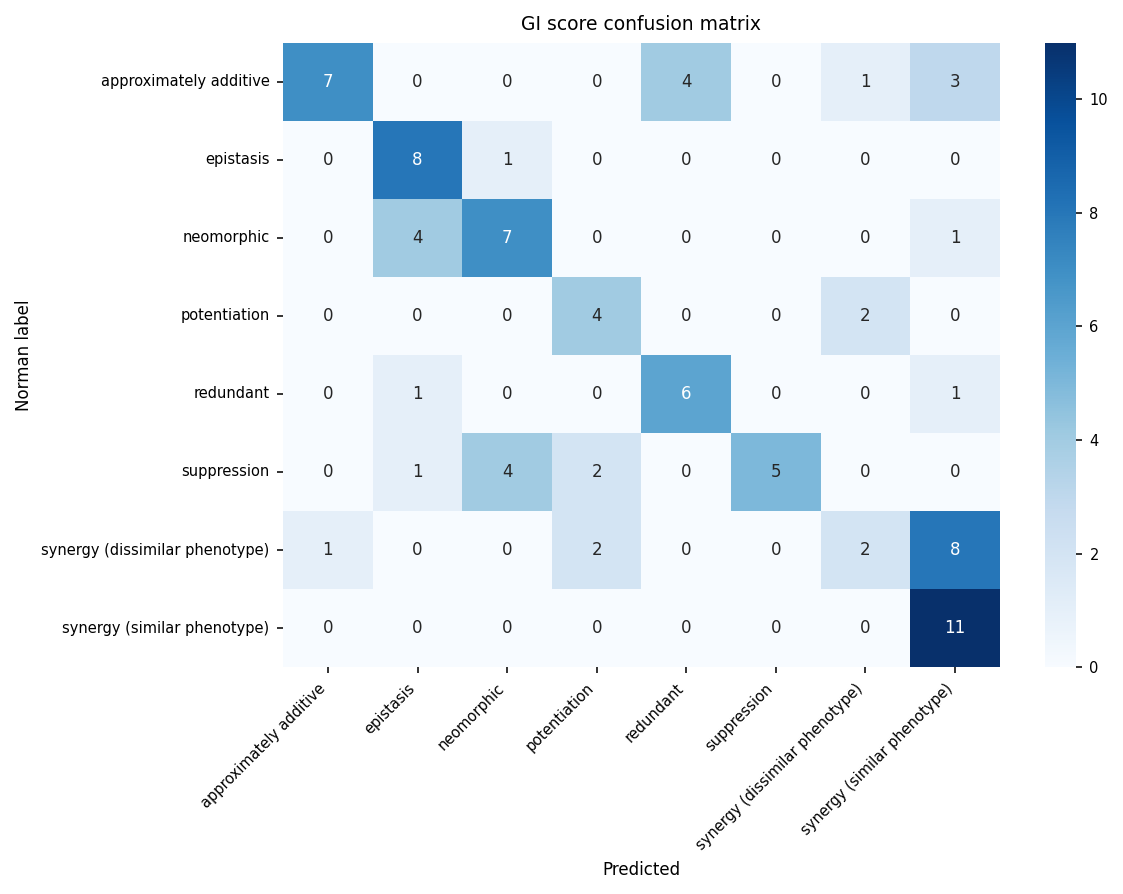

,pert_a,pert_b,n_a,n_b,n_ab,magnitude,dominance,model_fit,singles_similarity,singles_to_doubles,...,orthogonal_residual_fraction,cos_fit_resid_a,cos_fit_resid_b,cos_fit_resid_ab,cos_add_resid_a,cos_add_resid_b,cos_add_resid_ab,signed_residual_alignment,gt_gi,predicted_gi
AHR+FEV,AHR,FEV,558,703,276,1.607697,0.254441,0.914756,0.556235,0.892848,...,0.977737,-0.180701,-0.192280,0.078510,0.065917,-0.355220,0.097538,0.097538,synergy (dissimilar phenotype),synergy (dissimilar phenotype)
AHR+KLF1,AHR,KLF1,558,1954,481,1.049503,0.380004,0.942886,0.242222,0.734593,...,0.941235,-0.151289,-0.305664,-0.114180,-0.900327,-0.205582,-0.360422,-0.360422,epistasis,epistasis
BAK1+BCL2L11,BAK1,BCL2L11,1451,582,175,0.837992,0.342686,0.329362,0.556362,0.607331,...,0.913821,0.132516,0.385457,0.814158,-0.624327,-0.706577,0.041727,0.041727,NaN,neomorphic
BAK1+KLF1,BAK1,KLF1,1451,1954,392,0.773675,1.244421,0.927020,0.396883,0.915291,...,0.982987,-0.067573,-0.183536,0.084026,-0.677305,-0.763166,-0.616933,-0.616933,NaN,epistasis
BAK1+TMSB4X,BAK1,TMSB4X,1451,542,328,1.156073,0.403207,0.691176,0.168139,0.666924,...,0.996787,-0.002471,-0.079592,0.486168,-0.475717,0.063706,0.438681,0.438681,NaN,neomorphic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SNAI1+UBASH3B,SNAI1,UBASH3B,466,1201,299,1.290114,0.020225,0.880951,0.482099,0.891850,...,0.952826,0.006004,-0.289662,0.187884,-0.175247,-0.483671,-0.054520,-0.054520,synergy (dissimilar phenotype),potentiation
SNAI1+ZBTB10,SNAI1,ZBTB10,466,160,100,1.671866,0.321277,0.958631,0.838698,0.961357,...,0.993210,-0.074664,-0.017895,0.156305,-0.080890,-0.271387,-0.002862,-0.002862,approximately additive,synergy (similar phenotype)
TBX2+TBX3,TBX2,TBX3,689,689,1164,0.943538,0.008446,0.960582,0.748628,0.938296,...,0.988877,-0.092494,-0.143900,0.073296,-0.882283,-0.894953,-0.849479,-0.849479,approximately additive,redundant
UBASH3A+UBASH3B,UBASH3A,UBASH3B,817,1201,554,1.445536,0.274371,0.878054,0.831582,0.891922,...,0.978415,-0.203358,-0.194959,0.145676,-0.088051,0.025961,0.336692,0.336692,NaN,synergy (similar phenotype)


In [9]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def classify_and_report_gi(
    syn_df,
    gt_path="./genetic_interactions.csv",
    pred_col="predicted_gi",
    inplace=True,
    figsize=(8, 6),
):
    def canon_pair(s):
        s = str(s)
        if "+" not in s:
            return s
        a, b = s.split("+", 1)
        return "+".join(sorted([a.strip(), b.strip()]))

    if not os.path.exists(gt_path):
        raise FileNotFoundError(f"Expected {gt_path} for Norman labels.")

    gt = pd.read_csv(gt_path)
    gt["combination"] = gt["combination"].map(canon_pair)
    gt["genetic_interaction"] = gt["genetic_interaction"].astype(str).str.strip()

    eval_combinations = set(gt["combination"])
    syn_combinations = (
        syn_df["pert_a"].astype(str) + "+" + syn_df["pert_b"].astype(str)
    ).map(canon_pair)

    classified = slk.tl.classify_gi(
        syn_df,
        pred_col=pred_col,
        # fit_mask=syn_combinations.isin(eval_combinations),
        inplace=inplace,
    )

    score_df = classified.copy()
    score_df["combination"] = syn_combinations
    score_df = score_df.merge(
        gt[["combination", "genetic_interaction"]],
        on="combination",
        how="inner",
    )
    score_df = score_df.loc[score_df[pred_col].notna()].copy()

    y_true = score_df["genetic_interaction"].astype(str)
    y_pred = score_df[pred_col].astype(str)
    labels = sorted(y_true.unique())

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", labels=labels)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", labels=labels)

    print(f"Evaluated {len(score_df)} labeled interactions.")
    print(f"Accuracy:    {acc:.3f}")
    print(f"Macro F1:    {macro_f1:.3f}")
    print(f"Weighted F1: {weighted_f1:.3f}")
    print()
    print("Classification report:")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Norman label")
    ax.set_title("GI score confusion matrix")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return classified

classify_and_report_gi(syn)
# gears_gi = classify_and_report_gi(gears_gi)


In [10]:
UMAP_PATH     = OUT_DIR / 'umap_singlepert.npz'
UMAP_ALL_PATH = OUT_DIR / 'umap_allpert.npz'

single_mask = (
    (data.obs[p_key] != NTC) &
    (~data.obs['perturbation_name'].astype(str).str.contains(r'\+', regex=True))
)
sub = data[single_mask].copy()

# All non-NTC cells (singles + combos) for panel C
all_mask = data.obs[p_key] != NTC
all_sub  = data[all_mask].copy()
all_sub.obs['pert_type'] = np.where(
    all_sub.obs[p_key].astype(str).str.contains(r'\+', regex=True),
    'combination', 'single',
)

if _cache_fresh(UMAP_PATH, checkpoints[best_run]):
    print(f'Loading cached single-pert UMAP from {UMAP_PATH}')
    _u = np.load(UMAP_PATH, allow_pickle=True)
    sub.obsm['X_umap'] = _u['coords']
else:
    sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
    sc.tl.umap(sub)
    np.savez(UMAP_PATH, coords=sub.obsm['X_umap'])
    print(f'Single-pert UMAP saved to {UMAP_PATH}')

if _cache_fresh(UMAP_ALL_PATH, checkpoints[best_run]):
    print(f'Loading cached all-pert UMAP from {UMAP_ALL_PATH}')
    _u2 = np.load(UMAP_ALL_PATH, allow_pickle=True)
    all_sub.obsm['X_umap'] = _u2['coords']
else:
    sc.pp.neighbors(all_sub, n_neighbors=15, use_rep='z')
    sc.tl.umap(all_sub)
    np.savez(UMAP_ALL_PATH, coords=all_sub.obsm['X_umap'])
    print(f'All-pert UMAP saved to {UMAP_ALL_PATH}')

print(f'Single-pert cells: {sub.n_obs}  |  All-pert cells: {all_sub.n_obs}')

Loading cached single-pert UMAP from results/norman_figure/umap_singlepert.npz
Loading cached all-pert UMAP from results/norman_figure/umap_allpert.npz
Single-pert cells: 57735  |  All-pert cells: 99420


## 5. GEARS multi-run training & GI classification

In [11]:
from sklearn.metrics import (
    f1_score, roc_auc_score, silhouette_score, silhouette_samples,
    adjusted_rand_score, normalized_mutual_info_score,
    adjusted_mutual_info_score,
)

GI_METRICS = [
    'additive_residual_norm', 'dominance',
    'parent_dcor_diff', 'equality_contribution', 'singles_similarity',
    'norm_ab_over_additive', 'norm_fit_over_ab', 'magnitude',
    'model_fit_dcor', 'norm_fit', 'signed_residual_alignment',
]


# ── Merge the two synergy sub-types into a single 'synergy' class ───────
# Norman splits synergy into (similar phenotype) / (dissimilar phenotype). For
# the GI classification figure we score them as ONE class. This must happen
# BEFORE metrics are computed: the per-class F1/AUC of two one-vs-rest classes
# cannot be averaged into a merged class after the fact.
# Only the *metrics* are merged — the returned `work` frame keeps the original
# 8 labels, so Panel D's UMAP colouring is unchanged.
MERGE_SYNERGY = True
_SYNERGY_ALIASES = {
    'synergy (similar phenotype)':    'synergy',
    'synergy (dissimilar phenotype)': 'synergy',
}

def _merge_syn(s):
    """Collapse syn-sim / syn-dis -> 'synergy' (no-op if MERGE_SYNERGY is False)."""
    s = s.astype(str)
    return s.replace(_SYNERGY_ALIASES) if MERGE_SYNERGY else s


def evaluate_gi_classification(df, model_name, gi_series):
    """Classify GI for all combinations; evaluate against GT where available."""
    work = df.copy()
    if 'pert_a' in work.columns and 'pert_b' in work.columns:
        work.index = (work['pert_a'].astype(str) + '+' + work['pert_b'].astype(str)).map(canon_pair)
    else:
        work.index = work.index.map(canon_pair)

    work['gt_gi'] = work.index.map(gi_series)

    # Classify ALL rows with finite metrics (no fit_mask) so unlabelled combos get predictions too
    work = classify_gi(work, inplace=True)

    eval_df = work[work['gt_gi'].notna() & work['predicted_gi'].notna()].copy()
    y_true  = _merge_syn(eval_df['gt_gi'])
    y_pred  = _merge_syn(eval_df['predicted_gi'])
    labels  = sorted(set(y_true))

    per_class = []
    for cls in labels:
        tb = (y_true == cls).astype(int)
        pb = (y_pred == cls).astype(int)
        n_pos = int(tb.sum())
        auc = roc_auc_score(tb, pb) if 0 < n_pos < len(tb) else np.nan
        per_class.append({
            'model': model_name, 'class': cls, 'n_positive': n_pos,
            'f1': f1_score(tb, pb, zero_division=0), 'auc_roc': auc,
        })

    summary = {
        'model':       model_name,
        'n_eval':      len(eval_df),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'ari':         adjusted_rand_score(y_true, y_pred),
        'ami':         adjusted_mutual_info_score(y_true, y_pred),
        'nmi':         normalized_mutual_info_score(y_true, y_pred),
    }
    return work, pd.DataFrame(per_class), summary


slk_classified, slk_class_df, slk_summary = evaluate_gi_classification(syn, 'SHERLOCK', gi_series)

In [12]:
# ── GEARS multi-run training ─────────────────────────────────────────────
# Mirrors norman_run.ipynb: trains GEARS on data_train (held-out val_combos
# excluded, same split SHERLOCK uses) and predicts on gears_combos = all
# combinations observed in the full `data` (train-visible + held-out), i.e.
# train_gears(data_train, combos=get_observed_combinations(data, ...)).
# Runs N_RUNS times for CI in panel E; each run's model checkpoint, raw
# predictions, and classified metrics are cached independently so a run that
# already finished (even if a later run was interrupted) is never redone.
import sherlock.tools._gears as gears_tools
slk.tl.run_gears_gi              = gears_tools.run_gears_gi
slk.tl.get_observed_combinations = gears_tools.get_observed_combinations

GEARS_MODELS_DIR = OUT_DIR / 'gears_models'
GEARS_RUNS_DIR   = OUT_DIR / 'gears_runs'
GEARS_MODELS_DIR.mkdir(parents=True, exist_ok=True)
GEARS_RUNS_DIR.mkdir(parents=True, exist_ok=True)
GEARS_CLS_CACHE  = OUT_DIR / 'gears_per_run_class.csv'
GEARS_SUMM_CACHE = OUT_DIR / 'gears_per_run_summ.csv'

gears_combos = slk.tl.get_observed_combinations(data, pert_key=p_key, ntc_label=NTC)
print(f'GEARS combos (observed in full data, train + held-out): {len(gears_combos)}')
gears_singles = gears_tools.get_single_perturbations(data, pert_key=p_key, ntc_label=NTC)
print(f'GEARS singles (observed in full data): {len(gears_singles)}')

from scipy.sparse import csr_matrix, issparse

data_train_gears = data_train.copy()
_X_gears = data_train_gears.X
if issparse(_X_gears):
    _X_gears = _X_gears.toarray()
_X_gears = 1e4 * _X_gears / np.sum(_X_gears, axis=1, keepdims=True)
_X_gears = np.log2(_X_gears + 1)
data_train_gears.X = csr_matrix(_X_gears)  # GEARS assumes sparse .X, calls .toarray() internally

if GEARS_CLS_CACHE.exists() and GEARS_SUMM_CACHE.exists():
    _gears_run_class_df = pd.read_csv(GEARS_CLS_CACHE)
    _gears_run_summ_df  = pd.read_csv(GEARS_SUMM_CACHE)
else:
    _gears_run_class_df = pd.DataFrame(columns=['run'])
    _gears_run_summ_df  = pd.DataFrame(columns=['run'])
_gears_done_runs = set(_gears_run_summ_df['run'].unique().tolist())

gears_df = gears_classified = gears_class_df = gears_summary = None

for _rn in range(1, N_RUNS + 1):
    _pred_path = GEARS_RUNS_DIR / f'gears_gi_run{_rn}.csv'
    _ckpt_dir  = GEARS_MODELS_DIR / f'run_{_rn}'
    _has_ckpt  = (_ckpt_dir / 'config.pkl').exists()
    _preds_fresh = _has_ckpt and _cache_fresh(_pred_path, _ckpt_dir)

    if _rn in _gears_done_runs and _preds_fresh:
        print(f'GEARS run {_rn}/{N_RUNS}: metrics already cached and up to date, skipping.')
        gears_df = pd.read_csv(_pred_path)
        continue

    print(f'\n── GEARS run {_rn}/{N_RUNS} ──────────────────────────')
    _seed = SEED_BASE + _rn - 1
    random.seed(_seed)
    np.random.seed(_seed)
    torch.manual_seed(_seed)

    if _preds_fresh:
        print(f'  loading cached predictions from {_pred_path}')
        _gears_df_r = pd.read_csv(_pred_path)
        _ate_metrics_r = None
    else:
        _gears_run = slk.tl.run_gears_gi(
            data_train_gears,
            combos=gears_combos,
            data_dir='./gears_data',
            dataset_name='norman_figure_gears',
            pert_key=p_key,
            ntc_label=NTC,
            split='all',
            seed=_seed,
            batch_size=256,
            test_batch_size=1024,
            epochs=20,
            load_path=str(_ckpt_dir) if _has_ckpt else None,
            model_path=None if _has_ckpt else str(_ckpt_dir),
            verbose=True,
            quiet_steps=True,
            device=str(DEVICE),
        )
        _gears_df_r = _gears_run.gi if _gears_run.gi is not None else _gears_run.predictions
        _gears_df_r.to_csv(_pred_path, index=False)
        _ate_metrics_r = _gears_run.compute_ate(
            gears_singles + gears_combos, data.uns['treat_effect'], val_combos,
            already_normalized=True, verbose=False,
        )

    _classified_r, _cls_r, _summ_r = evaluate_gi_classification(_gears_df_r, 'GEARS', gi_series)
    _summ_r = {
        **_summ_r,
        **(_ate_metrics_r or {'ate_all': float('nan'), 'ate_single': float('nan'),
                               'ate_combo': float('nan'), 'ate_held': float('nan')}),
    }
    _cls_r = _cls_r.copy()
    _cls_r['run'] = _rn

    _gears_run_class_df = pd.concat([_gears_run_class_df, _cls_r], ignore_index=True)
    _gears_run_summ_df  = pd.concat(
        [_gears_run_summ_df, pd.DataFrame([{**_summ_r, 'run': _rn}])], ignore_index=True,
    )
    _gears_run_class_df.to_csv(GEARS_CLS_CACHE, index=False)
    _gears_run_summ_df.to_csv(GEARS_SUMM_CACHE, index=False)
    _gears_done_runs.add(_rn)

    gears_df, gears_classified, gears_class_df, gears_summary = (
        _gears_df_r, _classified_r, _cls_r, _summ_r,
    )
    print(f"  run {_rn}: f1_weighted={_summ_r['f1_weighted']:.4f}  "
          f"ate_all={_summ_r['ate_all']:.4f}  "
          f"ari={_summ_r['ari']:.4f}  ami={_summ_r['ami']:.4f}")

# If every run was already cached, reload the last run's predictions so
# downstream single-instance uses (UMAP fit, summary table) have a
# representative GEARS model.
if gears_classified is None:
    gears_df = pd.read_csv(GEARS_RUNS_DIR / f'gears_gi_run{N_RUNS}.csv')
    gears_classified, gears_class_df, gears_summary = evaluate_gi_classification(
        gears_df, 'GEARS', gi_series,
    )

print(f'\nGEARS per-run metrics:')
print(_gears_run_summ_df[['run', 'ate_all', 'f1_weighted', 'ari', 'ami']].to_string(index=False))

class_df   = pd.concat([slk_class_df, gears_class_df], ignore_index=True)
summary_df = pd.DataFrame([slk_summary, gears_summary])
class_df.to_csv(OUT_DIR / 'gi_classification.csv', index=False)

for name, clf in [('SHERLOCK', slk_classified), ('GEARS', gears_classified)]:
    n_pred = clf['predicted_gi'].notna().sum()
    n_nan  = clf['predicted_gi'].isna().sum()
    print(f'{name}: {n_pred} predicted, {n_nan} NaN (should be 0 if all metrics finite)')

print(summary_df.to_string(index=False))

GEARS combos (observed in full data, train + held-out): 131
GEARS singles (observed in full data): 105
GEARS run 1/5: metrics already cached and up to date, skipping.
GEARS run 2/5: metrics already cached and up to date, skipping.
GEARS run 3/5: metrics already cached and up to date, skipping.
GEARS run 4/5: metrics already cached and up to date, skipping.
GEARS run 5/5: metrics already cached and up to date, skipping.

GEARS per-run metrics:
 run  ate_all  f1_weighted      ari      ami
   1 0.835763     0.579606 0.359141 0.412483
   2 0.834157     0.606986 0.384964 0.433236
   3 0.831698     0.580320 0.370381 0.416559
   4 0.836410     0.575354 0.331174 0.392514
   5 0.832024     0.645127 0.400314 0.480865
SHERLOCK: 131 predicted, 0 NaN (should be 0 if all metrics finite)
GEARS: 130 predicted, 0 NaN (should be 0 if all metrics finite)
   model  n_eval  f1_weighted      ari      ami      nmi
SHERLOCK      86     0.665476 0.436843 0.500265 0.568168
   GEARS      86     0.645127 0.400314

In [13]:
# ── Per-run GI classification for SHERLOCK — used for CI in panel E ─────
# Runs get_gi + classify_gi on every checkpoint and caches results.
# Cache filename encodes the labelling, so flipping MERGE_SYNERGY busts the
# cache automatically instead of silently reusing rows with the old classes.
_suffix     = '_synmerged' if MERGE_SYNERGY else ''
_cls_cache  = OUT_DIR / f'gi_per_run_class{_suffix}.csv'
_summ_cache = OUT_DIR / f'gi_per_run_summ{_suffix}.csv'

if _cache_fresh(_cls_cache, *checkpoints.values()) and _cache_fresh(_summ_cache, *checkpoints.values()):
    print('Loading cached per-run GI metrics...')
    _run_class_df = pd.read_csv(_cls_cache)
    _run_summ_df  = pd.read_csv(_summ_cache)
else:
    _cls_rows, _summ_rows = [], []
    for _rn in range(1, N_RUNS + 1):
        _ckpt = checkpoints[_rn]
        if not _ckpt.exists():
            print(f'  Run {_rn}: checkpoint not found, skipping.')
            continue
        print(f'  Run {_rn}/{N_RUNS}...', end=' ', flush=True)
        _m = slk.tl.load_results(_ckpt)
        slk.tl.eval_single(_m, data, obsm_key='z', uns_key='results', device=DEVICE)
        _syn_r = _m.get_gi(data, min_cells=5)
        _syn_r.index = (
            _syn_r['pert_a'].astype(str) + '+' + _syn_r['pert_b'].astype(str)
        ).map(canon_pair)
        _syn_r['gt_gi'] = _syn_r.index.map(gi_series)
        _fit_r = _syn_r.index.to_series().isin(set(gi_labels['combination']))
        _syn_r  = classify_gi(_syn_r, fit_mask=_fit_r, inplace=True)
        _, _cls_r, _summ_r = evaluate_gi_classification(_syn_r, 'SHERLOCK', gi_series)
        _cls_r['run']  = _rn
        _summ_r['run'] = _rn
        _cls_rows.append(_cls_r)
        _summ_rows.append(_summ_r)
        print('done')
    _run_class_df = pd.concat(_cls_rows, ignore_index=True)
    _run_summ_df  = pd.DataFrame(_summ_rows)
    _run_class_df.to_csv(_cls_cache, index=False)
    _run_summ_df.to_csv(_summ_cache, index=False)
    print(f'Per-run GI metrics cached.')

# ── Rebuild GEARS per-run metrics under the merged-synergy labelling ─────
# GEARS' cached per-class/summary CSVs were computed with the 8-class labelling.
# Recompute them from the cached RAW predictions (gears_runs/gears_gi_run*.csv)
# so both models are scored with the same merged classes. No GEARS retraining and
# no cache files are overwritten. The ate_* columns are carried over from the
# on-disk summary cache: they are unaffected by the GI relabelling, and
# compute_ate() would need the GEARS model object, which we do not reload.
_g_cls_rows, _g_summ_rows = [], []
for _rn in range(1, N_RUNS + 1):
    _g_raw = pd.read_csv(GEARS_RUNS_DIR / f'gears_gi_run{_rn}.csv')
    _, _gc_r, _gs_r = evaluate_gi_classification(_g_raw, 'GEARS', gi_series)
    _gc_r = _gc_r.copy()
    _gc_r['run'] = _rn
    _g_cls_rows.append(_gc_r)
    _g_summ_rows.append({**_gs_r, 'run': _rn})

_gears_run_class_df = pd.concat(_g_cls_rows, ignore_index=True)
_ate_cols  = ['ate_all', 'ate_single', 'ate_combo', 'ate_held']
_gears_ate = pd.read_csv(GEARS_SUMM_CACHE)[['run'] + _ate_cols]
_gears_run_summ_df = pd.DataFrame(_g_summ_rows).merge(_gears_ate, on='run', how='left')
print(f'GEARS per-run metrics rebuilt with merged synergy (ate_* preserved).')


# ── CI-ready long dataframes used by panel E ─────────────────────────────
# SHERLOCK and GEARS all have N_RUNS rows per class — all get CI bars
class_df_ci = pd.concat(
    [_run_class_df, _gears_run_class_df], ignore_index=True,
)

# For summary metrics
_SUMM_KEYS = ['f1_weighted', 'ari', 'ami']
_SUMM_NAMES = {'f1_weighted': 'F1', 'ari': 'ARI', 'ami': 'AMI'}
_slk_run_long = _run_summ_df[['run'] + _SUMM_KEYS].melt(
    id_vars='run', value_vars=_SUMM_KEYS, var_name='metric', value_name='score'
)
_slk_run_long['model'] = 'SHERLOCK'
_gears_run_long = _gears_run_summ_df[['run'] + _SUMM_KEYS].melt(
    id_vars='run', value_vars=_SUMM_KEYS, var_name='metric', value_name='score'
)
_gears_run_long['model'] = 'GEARS'
summ_long_ci = pd.concat(
    [_slk_run_long[['model', 'metric', 'score']],
     _gears_run_long[['model', 'metric', 'score']]],
    ignore_index=True,
)
summ_long_ci['Metric'] = pd.Categorical(
    summ_long_ci['metric'].map(_SUMM_NAMES),
    categories=list(_SUMM_NAMES.values()), ordered=True,
)
print(_run_summ_df[['run', 'f1_weighted', 'ari', 'ami']].to_string(index=False))

Loading cached per-run GI metrics...
GEARS per-run metrics rebuilt with merged synergy (ate_* preserved).
 run  f1_weighted      ari      ami
   1     0.595615 0.376125 0.402459
   2     0.656916 0.390343 0.455384
   3     0.665476 0.436843 0.500265
   4     0.611188 0.337919 0.413503
   5     0.595561 0.348652 0.437374


In [14]:
# ── Synergy UMAP — 12-metric embedding for SHERLOCK and GEARS ────────────
from sklearn.preprocessing import StandardScaler
from umap import UMAP


def _fit_umap(df, metrics):
    avail  = [c for c in metrics if c in df.columns]
    X      = df[avail].values.astype(float)
    good   = np.all(np.isfinite(X), axis=1)
    work   = df[good].copy()
    X_s    = StandardScaler().fit_transform(X[good])
    reducer = UMAP(n_neighbors=10, min_dist=0.25, random_state=42)
    emb    = reducer.fit_transform(X_s)
    work['UMAP1'] = emb[:, 0]
    work['UMAP2'] = emb[:, 1]
    return work


# ── Pick the highest-weighted-F1 model per method for the UMAPs (fresh) ──
# The UMAPs (and the derived summary + Panel D) use the best GI *classifier*
# per method — not the best-ATE run or the last GEARS run. Recompute the chosen
# models' GI tables from source (SHERLOCK: reload checkpoint + get_gi; GEARS: raw
# per-run preds) so a stale syn_best.csv can never feed the figure.
_slk_best_run   = int(_run_summ_df.loc[_run_summ_df['f1_weighted'].idxmax(), 'run'])
_gears_best_run = int(_gears_run_summ_df.loc[_gears_run_summ_df['f1_weighted'].idxmax(), 'run'])
print(f'UMAP models by weighted-F1  —  SHERLOCK run {_slk_best_run}  |  GEARS run {_gears_best_run}')

_slk_best_model = slk.tl.load_results(checkpoints[_slk_best_run])
slk.tl.eval_single(_slk_best_model, data, obsm_key='z', uns_key='results', device=DEVICE)
_syn_bestf1 = _slk_best_model.get_gi(data, min_cells=5)
slk_classified, slk_class_df, slk_summary = evaluate_gi_classification(
    _syn_bestf1, 'SHERLOCK', gi_series)

_gears_bestf1_raw = pd.read_csv(GEARS_RUNS_DIR / f'gears_gi_run{_gears_best_run}.csv')
gears_classified, gears_class_df, gears_summary = evaluate_gi_classification(
    _gears_bestf1_raw, 'GEARS', gi_series)

syn_umap   = _fit_umap(slk_classified,   GI_METRICS)
gears_umap = _fit_umap(gears_classified, GI_METRICS)


def _cluster_metrics(umap_df, model_name, metrics):
    """Cluster quality metrics in the original metric space (not UMAP 2D)."""
    both  = umap_df[umap_df['gt_gi'].notna()].copy()
    avail = [c for c in metrics if c in both.columns]
    X_raw = both[avail].values.astype(float)
    finite = np.all(np.isfinite(X_raw), axis=1)
    both  = both[finite]
    X_s   = StandardScaler().fit_transform(X_raw[finite])
    y_gt  = both['gt_gi'].values.astype(str)
    y_pred = both['predicted_gi'].values.astype(str)
    if len(np.unique(y_gt)) > 1:
        _sil_s   = silhouette_samples(X_s, y_gt)
        _per_cls = pd.Series(_sil_s, index=y_gt).groupby(level=0).mean()
        sil      = float(_per_cls.mean())   # macro-average (equal weight per class)
    else:
        sil = float('nan')
    return {
        'model':      model_name,
        'silhouette': sil,
        'ari':        adjusted_rand_score(y_gt, y_pred),
        'nmi':        normalized_mutual_info_score(y_gt, y_pred),
    }


slk_clust   = _cluster_metrics(syn_umap,   'SHERLOCK', GI_METRICS)
gears_clust = _cluster_metrics(gears_umap, 'GEARS',    GI_METRICS)

for sd, cd in [(slk_summary, slk_clust), (gears_summary, gears_clust)]:
    sd['silhouette'] = cd['silhouette']
summary_df = pd.DataFrame([slk_summary, gears_summary])
print(summary_df[['model', 'f1_weighted', 'silhouette', 'ari', 'ami']].to_string(index=False))


# ── GI representative examples — used by panel D arrows & panel F heatmap ─
_cats_gi = ['approximately additive', 'epistasis', 'neomorphic',
            'potentiation', 'redundant', 'suppression', 'synergy']
_syn_all = {'synergy (similar phenotype)', 'synergy (dissimilar phenotype)', 'synergy'}
_val_set = set(val_combos)
_correct_gi = (
    (slk_classified['predicted_gi'] == slk_classified['gt_gi']) |
    (slk_classified['predicted_gi'].isin(_syn_all) & slk_classified['gt_gi'].isin(_syn_all))
)

_gi_examples = {}
_cbl_cnn1_idx = canon_pair('CBL+CNN1')
if _cbl_cnn1_idx in slk_classified.index:
    _gi_examples['synergy'] = slk_classified.loc[_cbl_cnn1_idx]
else:
    _p = slk_classified[slk_classified['gt_gi'].isin(_syn_all) &
                         slk_classified['predicted_gi'].isin(_syn_all)]
    _h = _p[_p.index.isin(_val_set)]
    _gi_examples['synergy'] = (_h if not _h.empty else _p).iloc[0]

for _cat in _cats_gi:
    if _cat == 'synergy':
        continue
    _p = slk_classified[_correct_gi & (slk_classified['gt_gi'] == _cat)]
    if _p.empty:
        continue
    _h = _p[_p.index.isin(_val_set)]
    _gi_examples[_cat] = (_h if not _h.empty else _p).iloc[0]

_gi_arrows = {}
for _cat, _row in _gi_examples.items():
    _na2, _nb2 = str(_row['pert_a']), str(_row['pert_b'])
    _cidx = canon_pair(f'{_na2}+{_nb2}')
    if _cidx in syn_umap.index:
        _gi_arrows[f'{_na2[:5]}/{_nb2[:5]}'] = _cidx

print(f'GI arrows ({len(_gi_arrows)}): {list(_gi_arrows.keys())}')

# ── Biologically motivated arrow annotations — GT-labelled pairs ──────────
HIGHLIGHT_COMBOS = {
    'DUSP9/MAPK1':   canon_pair('DUSP9+MAPK1'),
    'MAP2K6/SPI1':   canon_pair('MAP2K6+SPI1'),
    'CEBPA/B':       canon_pair('CEBPA+CEBPB'),
    'CBFA2T3/FEV':   canon_pair('FEV+CBFA2T3'),
    'CBL/PTPN12':    canon_pair('CBL+PTPN12'),
}

arrow_pairs = {}
for display, canonical in HIGHLIGHT_COMBOS.items():
    if canonical in syn_umap.index:
        row = syn_umap.loc[canonical]
        arrow_pairs[display] = canonical
        print(f'  GT  {display:18s} → GT: {row.get("gt_gi","N/A")}  Pred: {row.get("predicted_gi","N/A")}')
    else:
        print(f'  GT  {display:18s} not found in syn_umap')

# ── Novel annotations — unlabelled combinations of biological interest ────
NOVEL_COMBOS = {
    'BAK1/Bim':   canon_pair('BAK1+BCL2L11'),
    'p21/p27':    canon_pair('CDKN1A+CDKN1B'),
    'CEBPA/JUN':  canon_pair('CEBPA+JUN'),
    'UBASH3A/B':  canon_pair('UBASH3A+UBASH3B'),
}

novel_arrow_pairs = {}
for display, canonical in NOVEL_COMBOS.items():
    if canonical in syn_umap.index:
        row = syn_umap.loc[canonical]
        novel_arrow_pairs[display] = canonical
        print(f'  Novel {display:16s} → Pred: {row.get("predicted_gi","N/A")}')
    else:
        print(f'  Novel {display:16s} not found in syn_umap')

print(f'\n{len(arrow_pairs)} GT-labelled + {len(novel_arrow_pairs)} novel combinations annotated.')

UMAP models by weighted-F1  —  SHERLOCK run 3  |  GEARS run 5


regress_gi_params:   0%|          | 0/131 [00:00<?, ?pair/s]

/home/sc5625/.local/share/mamba/envs/sherlock/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   model  f1_weighted  silhouette      ari      ami
SHERLOCK     0.665476    0.011131 0.436843 0.500265
   GEARS     0.645127    0.041840 0.400314 0.480865
GI arrows (7): ['CBL/CNN1', 'BPGM/SAMD1', 'CEBPA/ZC3HA', 'KLF1/TGFBR', 'FEV/MAP7D', 'CEBPE/SPI1', 'CEBPB/PTPN1']
  GT  DUSP9/MAPK1        → GT: neomorphic  Pred: epistasis
  GT  MAP2K6/SPI1        → GT: neomorphic  Pred: epistasis
  GT  CEBPA/B            → GT: redundant  Pred: redundant
  GT  CBFA2T3/FEV        → GT: potentiation  Pred: potentiation
  GT  CBL/PTPN12         → GT: synergy (similar phenotype)  Pred: synergy (similar phenotype)
  Novel BAK1/Bim         → Pred: neomorphic
  Novel p21/p27          → Pred: redundant
  Novel CEBPA/JUN        → Pred: approximately additive
  Novel UBASH3A/B        → Pred: synergy (similar phenotype)

5 GT-labelled + 4 novel combinations annotated.


/home/sc5625/.local/share/mamba/envs/sherlock/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


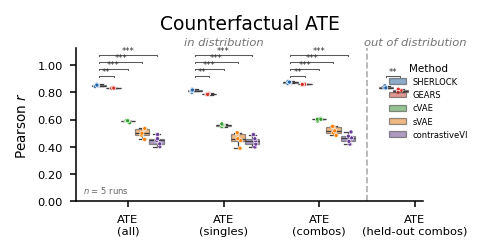

Panel A saved.


In [15]:
# ── Panel A: Counterfactual ATE — in-distribution and OOD ────────────────
METRIC_LABELS = {
    'ate_all':    'ATE\n(all)',
    'ate_single': 'ATE\n(singles)',
    'ate_combo':  'ATE\n(combos)',
    'ate_held':   'ATE\n(held-out combos)',
}

METHOD_ORDER = ['SHERLOCK', 'GEARS', 'cVAE', 'sVAE', 'contrastiveVI']
METHOD_PALETTE = {
    'SHERLOCK':      CLR_SHERLOCK,
    'cVAE':          '#33a02c',
    'sVAE':          '#ff7f00',
    'contrastiveVI': '#6a3d9a',
    'GEARS':         CLR_GEARS,
}

sherlock_ate_df = runs_df[['run'] + list(METRIC_LABELS)].copy()
sherlock_ate_df['method'] = 'SHERLOCK'
gears_ate_df = _gears_run_summ_df[['run'] + list(METRIC_LABELS)].copy()
gears_ate_df['method'] = 'GEARS'
all_ate_df = pd.concat(
    [sherlock_ate_df, gears_ate_df,
     bench_runs_df[['method', 'run'] + list(METRIC_LABELS)]],
    ignore_index=True,
)

df_long = all_ate_df.melt(
    id_vars=['method', 'run'],
    value_vars=list(METRIC_LABELS),
    var_name='metric', value_name='Pearson r',
)
df_long['Metric'] = pd.Categorical(
    df_long['metric'].map(METRIC_LABELS),
    categories=[METRIC_LABELS[k] for k in METRIC_LABELS],
    ordered=True,
)

TEXT_SCALE_A = -2.  # +/- pt added to all Panel A text uniformly; 0.0 == RC defaults
TEXT_SCALE_B = -1.5

fig_a, ax_a = plt.subplots(figsize=(300/PPI, 150/PPI), constrained_layout=True)

sns.boxplot(
    data=df_long, x='Metric', y='Pearson r', hue='method',
    hue_order=METHOD_ORDER, palette=METHOD_PALETTE,
    width=0.75, linewidth=0.6, fliersize=0, ax=ax_a,
    boxprops=dict(alpha=0.55),
)
sns.stripplot(
    data=df_long, x='Metric', y='Pearson r', hue='method',
    hue_order=METHOD_ORDER, palette=METHOD_PALETTE,
    dodge=True, size=2.6 + TEXT_SCALE_A/3, jitter=0.1,
    linewidth=0.3, edgecolor='white', ax=ax_a, legend=False,
)

ax_a.axvline(2.5, color='0.55', linewidth=0.8, linestyle='--', alpha=0.7)
ax_a.set_ylim(bottom=0)

# ── Significance: SHERLOCK vs every other method, per column ──────────────
# Welch's t-test on the per-run values, Benjamini-Hochberg FDR across all
# comparisons; drawn as R/ggsignif-style brackets with ns / * / ** / ***.
from scipy import stats as _stats
_sig_metrics = list(METRIC_LABELS)                 # ate_all, ate_single, ate_combo, ate_held
_sig_others  = [m for m in METHOD_ORDER if m != 'SHERLOCK']

def _mvals(_mk, _meth):
    return df_long[(df_long['metric'] == _mk) &
                   (df_long['method'] == _meth)]['Pearson r'].dropna().to_numpy()

_comps = []                                        # [col_i, other_method, p]
for _i, _mk in enumerate(_sig_metrics):
    _s = _mvals(_mk, 'SHERLOCK')
    for _o in _sig_others:
        _ov = _mvals(_mk, _o)
        if len(_s) < 2 or len(_ov) < 2:
            continue
        _comps.append([_i, _o, _stats.ttest_ind(_s, _ov, equal_var=False).pvalue])

# Benjamini-Hochberg across the whole family
_pv = np.array([c[2] for c in _comps])
_ord = np.argsort(_pv); _mtot = len(_pv); _adj = np.empty(_mtot); _prev = 1.0
for _k in range(_mtot - 1, -1, -1):
    _ix = _ord[_k]; _prev = min(_prev, _pv[_ix] * _mtot / (_k + 1)); _adj[_ix] = min(_prev, 1.0)
for _c, _pa in zip(_comps, _adj):
    _c.append(_pa)

def _stars(_p):
    return '***' if _p < 1e-3 else '**' if _p < 1e-2 else '*' if _p < 0.05 else 'ns'

# dodge geometry (boxplot width=0.75, one box per method)
_n_hue, _box_w = len(METHOD_ORDER), 0.75
def _xpos(_i, _meth):
    _j = METHOD_ORDER.index(_meth)
    return _i - _box_w / 2 + _box_w / (2 * _n_hue) + _j * (_box_w / _n_hue)

_y0   = float(df_long['Pearson r'].max()) + 0.03   # bracket base, above the boxes
_step = 0.052                                      # gap between stacked brackets
_tick = 0.012                                      # bracket end-tick height
_sfs  = 6 + TEXT_SCALE_A
_ytop = _y0
for _i in range(len(_sig_metrics)):
    _col = sorted([c for c in _comps if c[0] == _i],
                  key=lambda c: METHOD_ORDER.index(c[1]))   # nearest (GEARS) lowest
    for _lvl, (_, _o, _p, _pa) in enumerate(_col):
        _x1, _x2 = _xpos(_i, 'SHERLOCK'), _xpos(_i, _o)
        _y = _y0 + _lvl * _step
        ax_a.plot([_x1, _x1, _x2, _x2], [_y, _y + _tick, _y + _tick, _y],
                  lw=0.5, c='0.35', clip_on=False)
        ax_a.text((_x1 + _x2) / 2, _y + _tick, _stars(_pa),
                  ha='center', va='bottom', fontsize=_sfs, color='0.2', clip_on=False)
        _ytop = max(_ytop, _y + _tick)
ax_a.set_ylim(0, _ytop + 0.05)
_ylim = ax_a.get_ylim()
_y_ann = _ylim[1] + 0.07 * (_ylim[1] - _ylim[0])
ax_a.text(1.0, _y_ann, 'in distribution', ha='center', va='top',
          fontsize=5.5 , color='0.45', style='italic')
ax_a.text(3.0, _y_ann, 'out of distribution', ha='center', va='top',
          fontsize=5.5 , color='0.45', style='italic')

ax_a.set_xlabel('')
ax_a.set_ylabel('Pearson $r$', fontsize=mpl.rcParams['axes.labelsize'] + TEXT_SCALE_B)
ax_a.set_title('Counterfactual ATE', pad=9, fontsize=mpl.rcParams['axes.titlesize'] )
ax_a.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
ax_a.tick_params(axis='x', labelsize=mpl.rcParams['xtick.labelsize'] + TEXT_SCALE_B)
ax_a.tick_params(axis='y', labelsize=mpl.rcParams['ytick.labelsize'] + TEXT_SCALE_B)
ax_a.text(0.02, 0.04, f'$n$ = {N_RUNS} runs',
          transform=ax_a.transAxes, ha='left', va='bottom',
          fontsize=6 + TEXT_SCALE_A, color='0.4')
ax_a.legend(
    title='Method', frameon=False, loc='upper right',
    bbox_to_anchor=(1.15, 0.95),
    fontsize=mpl.rcParams['legend.fontsize'] + TEXT_SCALE_A,
    title_fontsize=mpl.rcParams['legend.title_fontsize'] + TEXT_SCALE_A,
)

fig_a.savefig(OUT_DIR / 'panel_a_ate.svg')
plt.show()
print('Panel A saved.')

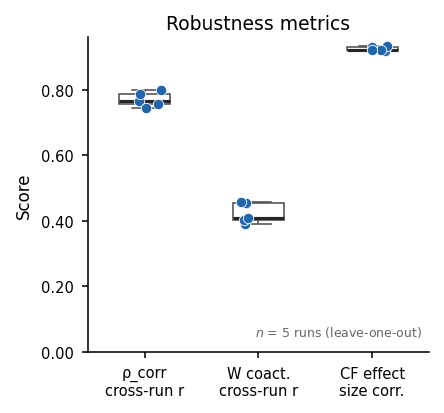

Panel B (robustness) saved.


In [16]:
# ── Panel B: Reproducibility / robustness metrics across N runs ───────────
ROBUST_LABELS = {
    'rho_corr_r':    'ρ_corr\ncross-run r',
    'w_coact_r':     'W coact.\ncross-run r',
    'effect_size_r': 'CF effect\nsize corr.',
}

df_robust = pd.concat([
    pairwise_df.rename(columns={'r': 'Score'})[['metric', 'Score']],
    runs_df[['effect_size_r']].rename(columns={'effect_size_r': 'Score'}).assign(metric='effect_size_r'),
], ignore_index=True)
df_robust['Metric'] = pd.Categorical(
    df_robust['metric'].map(ROBUST_LABELS),
    categories=[ROBUST_LABELS[k] for k in ROBUST_LABELS],
    ordered=True,
)

fig_b2, ax_b2 = plt.subplots(figsize=(3.0, 2.8))

sns.stripplot(
    data=df_robust, x='Metric', y='Score',
    color=CLR_SHERLOCK, size=5, jitter=0.15,
    linewidth=0.4, edgecolor='white', ax=ax_b2,
)
sns.boxplot(
    data=df_robust, x='Metric', y='Score',
    color='white', width=0.45, linewidth=0.75,
    fliersize=0, ax=ax_b2,
    boxprops=dict(edgecolor='0.3'),
    whiskerprops=dict(color='0.3'),
    capprops=dict(color='0.3'),
    medianprops=dict(color='0.15', linewidth=1.5),
)

ax_b2.set_ylim(bottom=0)
ax_b2.set_xlabel('')
ax_b2.set_ylabel('Score')
ax_b2.set_title('Robustness metrics', pad=4)
ax_b2.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
ax_b2.text(0.98, 0.04, f'$n$ = {N_RUNS} runs (leave-one-out)',
           transform=ax_b2.transAxes, ha='right', va='bottom',
           fontsize=6, color='0.4')

plt.tight_layout()
fig_b2.savefig(OUT_DIR / 'panel_b_robustness.svg', bbox_inches='tight')
plt.show()
print('Panel B (robustness) saved.')

In [17]:
slk_classified[slk_classified.index.str.contains('SET')]

,pert_a,pert_b,n_a,n_b,n_ab,magnitude,dominance,model_fit,singles_similarity,singles_to_doubles,...,orthogonal_residual_fraction,cos_fit_resid_a,cos_fit_resid_b,cos_fit_resid_ab,cos_add_resid_a,cos_add_resid_b,cos_add_resid_ab,signed_residual_alignment,gt_gi,predicted_gi
CEBPE+SET,CEBPE,SET,1230,985,657,0.636194,0.405684,0.836201,0.408361,0.836864,...,0.936462,0.338634,0.024743,0.536626,-0.880907,-0.639827,-0.730133,-0.730133,NaN,suppression
IRF1+SET,IRF1,SET,427,985,444,1.008506,0.220577,0.920936,0.641649,0.937512,...,0.982925,0.183550,0.122895,0.417788,-0.698836,-0.641002,-0.487001,-0.487001,approximately additive,approximately additive
KLF1+SET,KLF1,SET,1954,985,666,0.981713,0.129757,0.920894,0.315973,0.680678,...,0.927426,0.361948,-0.152576,0.438412,-0.020951,-0.873673,-0.475092,-0.475092,NaN,approximately additive
RHOXF2+SET,RHOXF2,SET,327,985,321,1.030692,0.086200,0.943632,0.625745,0.933921,...,0.983075,-0.183187,-0.102304,0.078453,-0.832574,-0.687881,-0.714507,-0.714507,NaN,suppression


Panel C subset: 45231 cells | 116 perturbations | 17 group categories (shown)


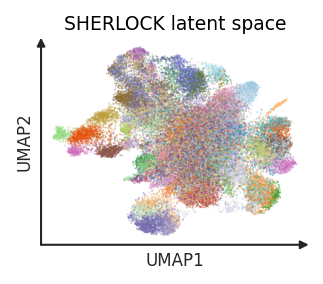

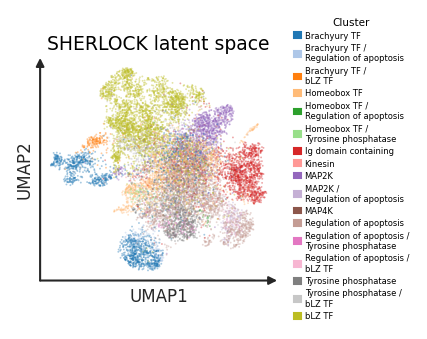

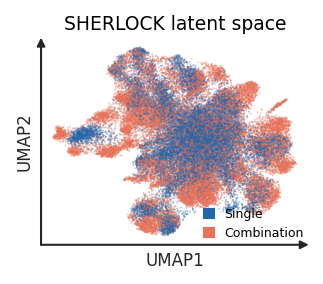

Panel C (3 UMAPs) saved.


In [18]:
# ── Panel C: SHERLOCK latent space — Excel-associated perturbations ───────
# Three UMAPs of the SAME subset (all labeled "SHERLOCK latent space"):
#   1. coloured by perturbation name
#   2. coloured by group/cluster (wide figure so the legend fits)
#   3. coloured by single vs combination
# Genes + groups are hard-coded from aax4438_tables6.xlsx (both sheets combined;
# any gene appearing in >1 cluster was dropped, then clusters left with <2 genes
# were dropped). Subset = singles that are group genes + any combo with >=1 group
# gene (the partner need not be a group gene). One fresh UMAP is fit on the subset
# (no cache file, so nothing can go stale).
#
# Group label (fig 2 only): single-group clusters are shown; a combo whose two
# genes fall in DIFFERENT groups ("cluster / cluster") is dropped; a combo with
# only one gene in a group collapses into that gene's named group.
GENE_GROUPS = {
    'MAP2K':                   ['MAP2K3', 'MAP2K6'],
    'Ig domain containing':    ['IGDCC3', 'PRTG'],
    'Tyrosine phosphatase':    ['PTPN12', 'PTPN9'],
    'MAP4K':                   ['MAP4K3', 'MAP4K5'],
    'Brachyury TF':            ['CSRNP1', 'SET', 'TBX2', 'TBX3'],
    'Kinesin':                 ['KIF18B', 'KIF2C'],
    'bLZ TF':                  ['CEBPA', 'CEBPB', 'CEBPE', 'CELF2', 'FOSB', 'OSR2'],
    'Regulation of apoptosis': ['EGR1', 'FOXO4', 'IER5L', 'IKZF3', 'MEIS1', 'PRDM1',
                                'RHOXF2B', 'SAMD1', 'SGK1', 'TP73'],
    'Homeobox TF':             ['CBFA2T3', 'CITED1', 'DLX2', 'MIDN', 'NIT1', 'SNAI1', 'TMSB4X'],
}
_gene2group = {g: grp for grp, genes in GENE_GROUPS.items() for g in genes}
_EXCEL_GENES = set(_gene2group)

def _in_subset(name):
    """Single that is a group gene, or a combo with >=1 group gene."""
    return any(p in _EXCEL_GENES for p in str(name).split('+'))

def _group_of(name):
    """Group label: a single group; 'group A / group B' when the two genes
    fall in different groups; or None (no group gene). A combo with only one
    gene in a group collapses to that group."""
    parts = str(name).split('+')
    if len(parts) == 1:
        return _gene2group.get(parts[0])
    ga, gb = _gene2group.get(parts[0]), _gene2group.get(parts[1])
    if ga and gb:
        return ga if ga == gb else ' / '.join(sorted([ga, gb]))  # two groups
    return ga or gb                              # one gene in a group -> its group

# ── Build subset from the SHERLOCK latent space (same 'z' as the full panel) ──
_c_mask = all_sub.obs[p_key].astype(str).map(_in_subset).values
c_sub   = all_sub[_c_mask].copy()
c_sub.obs['pert_name']   = c_sub.obs[p_key].astype(str).values
c_sub.obs['group_label'] = c_sub.obs['pert_name'].map(_group_of).values
c_sub.obs['pert_type']   = np.where(
    c_sub.obs['pert_name'].str.contains(r'\+', regex=True), 'combination', 'single')

sc.pp.neighbors(c_sub, n_neighbors=15, use_rep='z')
sc.tl.umap(c_sub, random_state=42)
_coords = c_sub.obsm['X_umap']
print(f'Panel C subset: {c_sub.n_obs} cells | '
      f"{c_sub.obs['pert_name'].nunique()} perturbations | "
      f"{c_sub.obs['group_label'].nunique()} group categories (shown)")

def _palette(cats):
    """Distinct qualitative colours (tab20 + tab20b + tab20c = 60), cycled."""
    cats = list(cats)
    base = (list(plt.get_cmap('tab20').colors)
            + list(plt.get_cmap('tab20b').colors)
            + list(plt.get_cmap('tab20c').colors))
    return {c: base[i % len(base)] for i, c in enumerate(cats)}

def _style_umap(ax, coords, color_vals, palette, title):
    ax.scatter(coords[:, 0], coords[:, 1],
               c=[palette[v] for v in color_vals],
               s=0.8, alpha=0.4, linewidths=0, rasterized=True)
    ax.set_xlabel(''); ax.set_ylabel(''); ax.set_title(title, pad=4)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    _add_umap_axis_indicator(ax, length=1.0)

_TITLE = 'SHERLOCK latent space'

# ── 1. coloured by perturbation name (many perturbations -> no legend) ────
_name_cats = sorted(c_sub.obs['pert_name'].unique())
_name_pal  = _palette(_name_cats)
fig_c1, ax_c1 = plt.subplots(figsize=(196/PPI, 171/PPI), constrained_layout=True)
_style_umap(ax_c1, _coords, c_sub.obs['pert_name'].values, _name_pal, _TITLE)
fig_c1.savefig(OUT_DIR / 'panel_c_umap_byname.svg')
plt.show()

# ── 2. coloured by group/cluster (incl. two-group combos), subsampled ─────
SUBSAMPLE_FRAC = 0.3  # fraction of cells drawn in this panel (density control)
TEXT_SCALE_C   = -1.0  # +/- pt on the cluster legend text (shrink to fit the figsize)
_grp_valid = c_sub.obs['group_label'].notna().values
_grp_vals  = c_sub.obs['group_label'].values
_grp_cats  = sorted(set(_grp_vals[_grp_valid]))
_grp_pal   = _palette(_grp_cats)
# subsample cells so the embedding reads less dense (legend keeps all cats)
_grp_plot  = _grp_valid & (np.random.default_rng(0).random(c_sub.n_obs) < SUBSAMPLE_FRAC)
fig_c2 = plt.figure(figsize=(285/PPI, 185/PPI))
_gs_c2  = fig_c2.add_gridspec(1, 2, width_ratios=[2.5, 1.0], wspace=0.08)
ax_c2   = fig_c2.add_subplot(_gs_c2[0, 0])
_ax_leg = fig_c2.add_subplot(_gs_c2[0, 1]); _ax_leg.axis('off')
_style_umap(ax_c2, _coords[_grp_plot], _grp_vals[_grp_plot], _grp_pal, _TITLE)
_ax_leg.legend(
    handles=[Patch(color=_grp_pal[g], label=g.replace(' / ', ' /\n')) for g in _grp_cats],
    loc='center left', frameon=False, fontsize=5 + TEXT_SCALE_C,
    handlelength=0.9, handletextpad=0.4, labelspacing=0.4, borderaxespad=0,
    title='Cluster', title_fontsize=6 + TEXT_SCALE_C,
)
fig_c2.savefig(OUT_DIR / 'panel_c_umap_bygroup.svg')
plt.show()

# ── 3. coloured by single vs combination ─────────────────────────────────
_type_pal = {'single': CLR_SHERLOCK, 'combination': '#E8735A'}
fig_c3, ax_c3 = plt.subplots(figsize=(196/PPI, 171/PPI), constrained_layout=True)
_style_umap(ax_c3, _coords, c_sub.obs['pert_type'].values, _type_pal, _TITLE)
ax_c3.legend(
    handles=[Patch(color=v, label=k.capitalize()) for k, v in _type_pal.items()],
    frameon=False, loc='lower right', handlelength=0.8, borderaxespad=0,
)
fig_c3.savefig(OUT_DIR / 'panel_c_umap_bytype.svg')
plt.show()

print('Panel C (3 UMAPs) saved.')

8 double groupings: ['Brachyury TF / Regulation of apoptosis', 'Brachyury TF / bLZ TF', 'Homeobox TF / Regulation of apoptosis', 'Homeobox TF / Tyrosine phosphatase', 'MAP2K / Regulation of apoptosis', 'Regulation of apoptosis / Tyrosine phosphatase', 'Regulation of apoptosis / bLZ TF', 'Tyrosine phosphatase / bLZ TF']


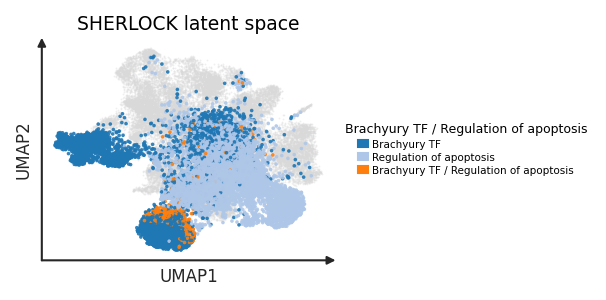

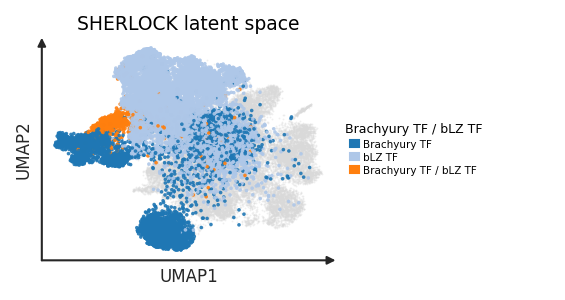

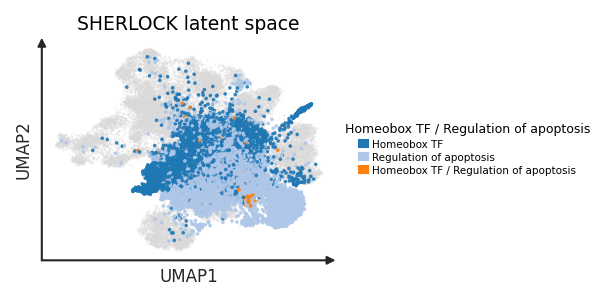

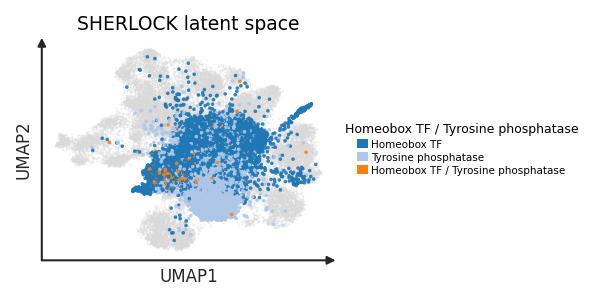

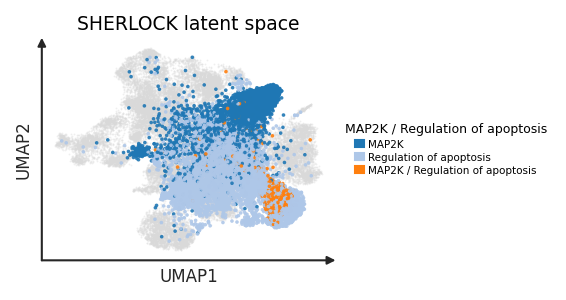

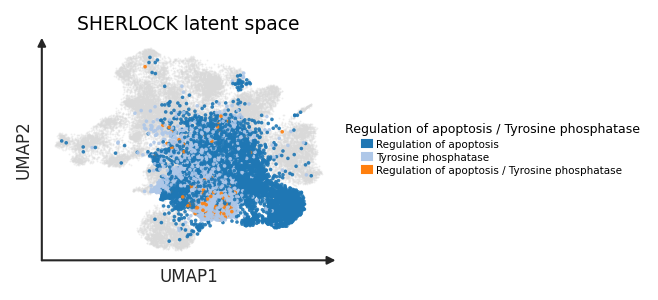

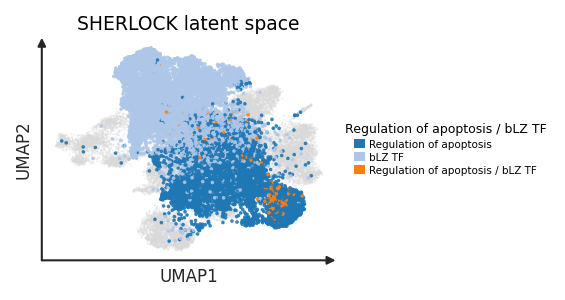

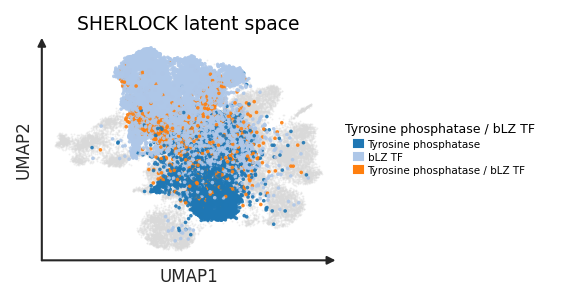

Double-group UMAPs saved.


In [19]:
# ── SHERLOCK latent space — one figure per double (two-group) cluster ─────
# For each "A / B" dual grouping, colour its combos plus the two single-group
# clusters A and B; everything else is grey. Uses the single shared manifold
# (_coords) built in the Panel C cell above.
_dual_labels = sorted(l for l in c_sub.obs['group_label'].dropna().unique()
                      if ' / ' in str(l))
print(f'{len(_dual_labels)} double groupings: {_dual_labels}')

for _dual in _dual_labels:
    _a, _b  = _dual.split(' / ')
    _cats   = [_a, _b, _dual]
    _pal    = _palette(_cats)               # A, B, A/B -> three distinct colours
    _gl     = c_sub.obs['group_label'].values
    _mask   = np.isin(_gl, _cats)

    fig_d  = plt.figure(figsize=(420/PPI, 185/PPI))
    _gs_d   = fig_d.add_gridspec(1, 2, width_ratios=[1.4, 1.0], wspace=0.02)
    ax_d    = fig_d.add_subplot(_gs_d[0, 0])
    _ax_dl  = fig_d.add_subplot(_gs_d[0, 1]); _ax_dl.axis('off')

    # grey background (everything not in A, B, or A/B)
    ax_d.scatter(_coords[~_mask, 0], _coords[~_mask, 1],
                 c='0.85', s=0.8, alpha=0.4, linewidths=0, rasterized=True)
    # A, B and the A/B combos on top
    ax_d.scatter(_coords[_mask, 0], _coords[_mask, 1],
                 c=[_pal[v] for v in _gl[_mask]],
                 s=3.0, alpha=0.9, linewidths=0, rasterized=True)

    ax_d.set_xlabel(''); ax_d.set_ylabel('')
    ax_d.set_title('SHERLOCK latent space', pad=4)
    ax_d.set_xticks([]); ax_d.set_yticks([])
    for sp in ax_d.spines.values():
        sp.set_visible(False)
    _add_umap_axis_indicator(ax_d, length=1.0)

    _ax_dl.legend(
        handles=[Patch(color=_pal[c], label=c) for c in _cats],
        loc='center left', frameon=False, fontsize=5,
        handlelength=0.9, handletextpad=0.4, labelspacing=0.3, borderaxespad=0,
        title=_dual, title_fontsize=6,
    )
    _svg = _dual.replace(' / ', '__').replace(' ', '_')
    fig_d.savefig(OUT_DIR / f'panel_c_umap_dual_{_svg}.svg', bbox_inches='tight')
    plt.show()

print('Double-group UMAPs saved.')

In [20]:
gi_labels[gi_labels['combination'].str.contains('PTPN12')]

,combination,genetic_interaction
9,FOSB+PTPN12,neomorphic
11,OSR2+PTPN12,neomorphic
27,PTPN12+UBASH3A,potentiation
38,PTPN12+SAMD1,approximately additive
53,CBL+PTPN12,synergy (similar phenotype)
60,PTPN12+UBASH3B,synergy (similar phenotype)
63,CEBPB+PTPN12,suppression
65,CEBPE+PTPN12,suppression
74,PTPN12+SNAI1,suppression
85,PTPN12+ZBTB25,synergy (dissimilar phenotype)


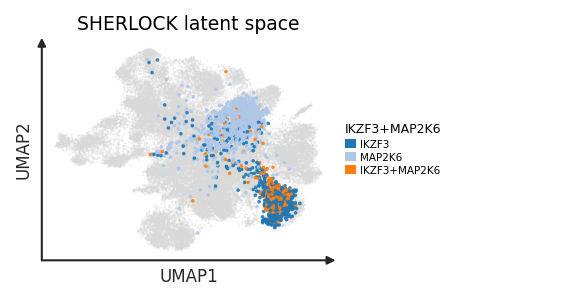

IKZF3+MAP2K6: 300 combo cells | 680 IKZF3 | 878 MAP2K6


In [21]:
# ── SHERLOCK latent space — one combo + its two singles ──────────────────
# Colours a chosen combo and its two constituent single perturbations by name;
# everything else grey. Uses the shared manifold (_coords) from the Panel C cell.
HIGHLIGHT_COMBO = 'IKZF3+MAP2K6'

_ca, _cb = HIGHLIGHT_COMBO.split('+')
_pn = c_sub.obs['pert_name'].astype(str)
_is_combo = _pn.map(lambda n: '+' in n and sorted(n.split('+')) == sorted([_ca, _cb])).values

_lab = pd.Series(index=c_sub.obs.index, dtype=object)
_lab[(_pn == _ca).values] = _ca
_lab[(_pn == _cb).values] = _cb
_lab[_is_combo]           = HIGHLIGHT_COMBO
_show = _lab.notna().values

_cats = [_ca, _cb, HIGHLIGHT_COMBO]
_pal  = _palette(_cats)

fig_hc = plt.figure(figsize=(420/PPI, 185/PPI))
_gs_hc  = fig_hc.add_gridspec(1, 2, width_ratios=[1.4, 1.0], wspace=0.02)
ax_hc   = fig_hc.add_subplot(_gs_hc[0, 0])
_ax_hcl = fig_hc.add_subplot(_gs_hc[0, 1]); _ax_hcl.axis('off')

# grey background (everything not in the combo or its singles)
ax_hc.scatter(_coords[~_show, 0], _coords[~_show, 1],
              c='0.85', s=0.8, alpha=0.4, linewidths=0, rasterized=True)
# the combo + its two singles on top
ax_hc.scatter(_coords[_show, 0], _coords[_show, 1],
              c=[_pal[l] for l in _lab.values[_show]],
              s=3.0, alpha=0.9, linewidths=0, rasterized=True)

ax_hc.set_xlabel(''); ax_hc.set_ylabel('')
ax_hc.set_title('SHERLOCK latent space', pad=4)
ax_hc.set_xticks([]); ax_hc.set_yticks([])
for sp in ax_hc.spines.values():
    sp.set_visible(False)
_add_umap_axis_indicator(ax_hc, length=1.0)

_ax_hcl.legend(
    handles=[Patch(color=_pal[c], label=c) for c in _cats],
    loc='center left', frameon=False, fontsize=5,
    handlelength=0.9, handletextpad=0.4, labelspacing=0.3, borderaxespad=0,
    title=HIGHLIGHT_COMBO, title_fontsize=6,
)
_svg = HIGHLIGHT_COMBO.replace('+', '_')
fig_hc.savefig(OUT_DIR / f'panel_c_umap_combo_{_svg}.svg', bbox_inches='tight')
plt.show()
print(f'{HIGHLIGHT_COMBO}: {int(_is_combo.sum())} combo cells | '
      f'{int((_pn == _ca).sum())} {_ca} | {int((_pn == _cb).sum())} {_cb}')

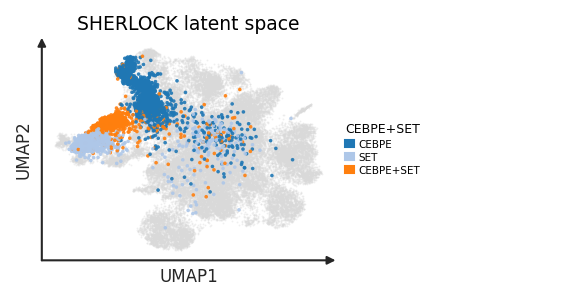

CEBPE+SET: 657 combo cells | 1230 CEBPE | 985 SET


In [22]:
# ── SHERLOCK latent space — one combo + its two singles ──────────────────
# Colours a chosen combo and its two constituent single perturbations by name;
# everything else grey. Uses the shared manifold (_coords) from the Panel C cell.
HIGHLIGHT_COMBO = 'CEBPE+SET'

_ca, _cb = HIGHLIGHT_COMBO.split('+')
_pn = c_sub.obs['pert_name'].astype(str)
_is_combo = _pn.map(lambda n: '+' in n and sorted(n.split('+')) == sorted([_ca, _cb])).values

_lab = pd.Series(index=c_sub.obs.index, dtype=object)
_lab[(_pn == _ca).values] = _ca
_lab[(_pn == _cb).values] = _cb
_lab[_is_combo]           = HIGHLIGHT_COMBO
_show = _lab.notna().values

_cats = [_ca, _cb, HIGHLIGHT_COMBO]
_pal  = _palette(_cats)

fig_hc = plt.figure(figsize=(420/PPI, 185/PPI))
_gs_hc  = fig_hc.add_gridspec(1, 2, width_ratios=[1.4, 1.0], wspace=0.02)
ax_hc   = fig_hc.add_subplot(_gs_hc[0, 0])
_ax_hcl = fig_hc.add_subplot(_gs_hc[0, 1]); _ax_hcl.axis('off')

# grey background (everything not in the combo or its singles)
ax_hc.scatter(_coords[~_show, 0], _coords[~_show, 1],
              c='0.85', s=0.8, alpha=0.4, linewidths=0, rasterized=True)
# the combo + its two singles on top
ax_hc.scatter(_coords[_show, 0], _coords[_show, 1],
              c=[_pal[l] for l in _lab.values[_show]],
              s=3.0, alpha=0.9, linewidths=0, rasterized=True)

ax_hc.set_xlabel(''); ax_hc.set_ylabel('')
ax_hc.set_title('SHERLOCK latent space', pad=4)
ax_hc.set_xticks([]); ax_hc.set_yticks([])
for sp in ax_hc.spines.values():
    sp.set_visible(False)
_add_umap_axis_indicator(ax_hc, length=1.0)

_ax_hcl.legend(
    handles=[Patch(color=_pal[c], label=c) for c in _cats],
    loc='center left', frameon=False, fontsize=5,
    handlelength=0.9, handletextpad=0.4, labelspacing=0.3, borderaxespad=0,
    title=HIGHLIGHT_COMBO, title_fontsize=6,
)
_svg = HIGHLIGHT_COMBO.replace('+', '_')
fig_hc.savefig(OUT_DIR / f'panel_c_umap_combo_{_svg}.svg', bbox_inches='tight')
plt.show()
print(f'{HIGHLIGHT_COMBO}: {int(_is_combo.sum())} combo cells | '
      f'{int((_pn == _ca).sum())} {_ca} | {int((_pn == _cb).sum())} {_cb}')

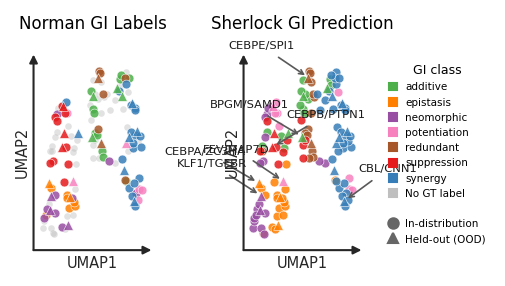

Panel D (synergy UMAP) saved.


In [23]:
# ── Panel D: Synergy UMAP — GT class (left) vs predicted class (right) ──
# Display-only relabelling: the two synergy sub-classes are shown as one
# "synergy" and "approximately additive" is shown as "additive". Underlying
# gt_gi / predicted_gi columns (and all metrics) are unchanged.
_GI_DISPLAY = {
    'synergy (similar phenotype)':    'synergy',
    'synergy (dissimilar phenotype)': 'synergy',
    'approximately additive':         'additive',
}
PALETTE_GI_DISPLAY = {
    'additive':     '#4DAF4A',  # green
    'epistasis':    '#FF7F00',  # orange
    'neomorphic':   '#984EA3',  # purple
    'potentiation': '#F781BF',  # pink
    'redundant':    '#A65628',  # brown
    'suppression':  '#E41A1C',  # red
    'synergy':      '#377EB8',  # blue
}

def _draw_synergy_umap(ax, umap_df, colour_col, title,
                       val_combos=None, arrow_pairs=None, show_unlabelled=False,
                       right_labels=None, show_axis=True, text_scale=0.0, margin=0.1):
    """
    colour_col: column to colour by (gt_gi or predicted_gi).
    show_unlabelled: if True, draw NaN rows as gray (for GT panel only).
    arrow_pairs: {display_label: canonical_idx}
    """
    labelled   = umap_df[umap_df[colour_col].notna()].copy()
    unlabelled = umap_df[umap_df[colour_col].isna()].copy()
    # merge synergy sub-classes -> 'synergy', 'approximately additive' -> 'additive'
    labelled[colour_col] = labelled[colour_col].map(lambda _s: _GI_DISPLAY.get(str(_s), _s))

    if show_unlabelled and len(unlabelled) > 0:
        ax.scatter(
            unlabelled['UMAP1'], unlabelled['UMAP2'],
            color='0.75', s=10, alpha=0.45, linewidths=0, zorder=1,
        )

    if val_combos is not None:
        in_dist  = labelled[~labelled.index.isin(val_combos)]
        out_dist = labelled[labelled.index.isin(val_combos)]
    else:
        in_dist  = labelled
        out_dist = labelled.iloc[0:0]

    for cls in sorted(labelled[colour_col].unique()):
        color   = PALETTE_GI_DISPLAY.get(str(cls), '#888888')
        grp_id  = in_dist[in_dist[colour_col] == cls]
        grp_ood = out_dist[out_dist[colour_col] == cls]
        if len(grp_id) > 0:
            ax.scatter(
                grp_id['UMAP1'], grp_id['UMAP2'],
                color=color, marker='o', s=18, alpha=0.85,
                linewidths=0.3, edgecolors='white', zorder=2,
            )
        if len(grp_ood) > 0:
            ax.scatter(
                grp_ood['UMAP1'], grp_ood['UMAP2'],
                color=color, marker='^', s=22, alpha=0.85,
                linewidths=0.3, edgecolors='white', zorder=3,
            )

    if arrow_pairs:
        for display_label, idx in arrow_pairs.items():
            if idx not in umap_df.index:
                continue
            row  = umap_df.loc[idx]
            x, y = float(row['UMAP1']), float(row['UMAP2'])
            _right = right_labels and display_label in right_labels
            ax.annotate(
                display_label,
                xy=(x, y), xytext=(x + 1.5 if _right else x - 1.5, y + 0.8),
                fontsize=6.5 + text_scale, color='0.1',
                ha='left' if _right else 'right', va='bottom',
                arrowprops=dict(
                    arrowstyle='->', color='0.35',
                    lw=0.8, shrinkA=2, shrinkB=2,
                ),
            )

    ax.margins(margin)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(title, pad=3, y=1.1, fontsize=mpl.rcParams['axes.titlesize'] + text_scale)
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    if show_axis:
        _add_umap_axis_indicator(ax, length=1.0, fontsize=mpl.rcParams['axes.labelsize'] + text_scale)


TEXT_SCALE = - 1.0  # +/- pt added to all Panel D text uniformly; 0.0 == RC defaults

fig_d, axes_d = plt.subplots(1, 2, figsize=(312/PPI, 172/PPI), constrained_layout=True)

_draw_synergy_umap(axes_d[0], syn_umap, 'gt_gi', 'Norman GI Labels',
                   val_combos=val_combos, arrow_pairs=None,
                   show_unlabelled=True, show_axis=True, text_scale=TEXT_SCALE, margin=0.1)
_draw_synergy_umap(axes_d[1], syn_umap, 'predicted_gi', 'Sherlock GI Prediction',
                   val_combos=val_combos, arrow_pairs=_gi_arrows,
                   show_unlabelled=False, show_axis=True, text_scale=TEXT_SCALE, margin=0.1,
                   right_labels={'CBL/CNN1', 'CEBPB/PTPN1'})

# Legend
SHOW_LEGEND = True  # temporarily off to check panel sizing on the 371x172px canvas
class_handles = [Patch(color=PALETTE_GI_DISPLAY.get(cls, '#888888'), label=cls)
                 for cls in sorted(PALETTE_GI_DISPLAY)]
extra_handles = [
    Patch(color='0.75', label='No GT label'),
    Patch(color='none', label=''),
    Line2D([0], [0], marker='o', color='0.4', linestyle='None', ms=5, label='In-distribution'),
    Line2D([0], [0], marker='^', color='0.4', linestyle='None', ms=5, label='Held-out (OOD)'),
]
if SHOW_LEGEND:
    axes_d[1].legend(
        handles=class_handles + extra_handles,
        title='GI class', frameon=False,
        fontsize=mpl.rcParams['legend.fontsize'] + TEXT_SCALE,
        title_fontsize=mpl.rcParams['legend.title_fontsize'] + TEXT_SCALE,
        bbox_to_anchor=(1.15, 1), loc='upper left',
        handlelength=0.8, handleheight=0.8,
    )

fig_d.savefig(OUT_DIR / 'panel_d_synergy_umap.svg')
plt.show()
print('Panel D (synergy UMAP) saved.')

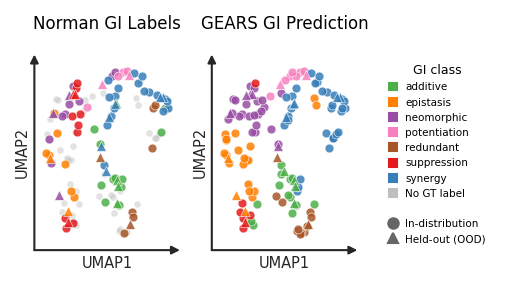

Panel D (GEARS synergy UMAP) saved.


In [24]:
# ── Panel D (GEARS): Synergy UMAP — GT class (left) vs GEARS predicted class (right) ──
fig_d_gears, axes_d_gears = plt.subplots(1, 2, figsize=(312/PPI, 172/PPI), constrained_layout=True)

_draw_synergy_umap(axes_d_gears[0], gears_umap, 'gt_gi', 'Norman GI Labels',
                   val_combos=val_combos, arrow_pairs=None,
                   show_unlabelled=True, show_axis=True, text_scale=TEXT_SCALE, margin=0.1)
_draw_synergy_umap(axes_d_gears[1], gears_umap, 'predicted_gi', 'GEARS GI Prediction',
                   val_combos=val_combos, #arrow_pairs=_gi_arrows,
                   show_unlabelled=False, show_axis=True, text_scale=TEXT_SCALE, margin=0.1,
                   right_labels={'CBL/CNN1', 'CEBPB/PTPN1'})

if SHOW_LEGEND:
    axes_d_gears[1].legend(
        handles=class_handles + extra_handles,
        title='GI class', frameon=False,
        fontsize=mpl.rcParams['legend.fontsize'] + TEXT_SCALE,
        title_fontsize=mpl.rcParams['legend.title_fontsize'] + TEXT_SCALE,
        bbox_to_anchor=(1.15, 1), loc='upper left',
        handlelength=0.8, handleheight=0.8,
    )

fig_d_gears.savefig(OUT_DIR / 'panel_d_synergy_umap_gears.svg')
plt.show()
print('Panel D (GEARS synergy UMAP) saved.')


/var/tmp/ipykernel_1076777/2468643541.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_e1.set_yticklabels([_CLASS_LABEL_MAP.get(c, c) for c in class_order])


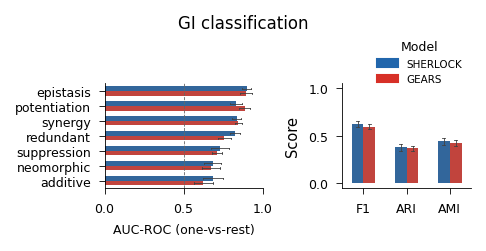

Panel E saved.


In [25]:
# ── Panel E: GI classification — per-class AUC (left) + summary (right) ──
MODEL_ORDER = ['SHERLOCK', 'GEARS']
class_order = (
    class_df_ci.groupby('class')['auc_roc']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
bar_pal = {'SHERLOCK': CLR_SHERLOCK, 'GEARS': CLR_GEARS}

TEXT_SCALE_E = -1.0  # +/- pt added to all Panel E text uniformly; 0.0 == RC defaults

fig_e, (ax_e1, ax_e2) = plt.subplots(
    1, 2, figsize=(300/PPI, 150/PPI), constrained_layout=True,
    gridspec_kw={'width_ratios': [2.2, 1.8]},
)

# Left: per-class AUC-ROC
sns.barplot(
    data=class_df_ci.dropna(subset=['auc_roc']),
    y='class', x='auc_roc',
    hue='model', hue_order=MODEL_ORDER,
    palette=bar_pal, order=class_order,
    width=0.62, errorbar='sd', capsize=0.15, err_kws={'linewidth': 0.4}, ax=ax_e1, legend=False,
)
ax_e1.axvline(0.5, color='0.4', linewidth=0.4, linestyle='--')
ax_e1.set_xlabel('AUC-ROC (one-vs-rest)', fontsize=mpl.rcParams['axes.labelsize'] + TEXT_SCALE_E - 1)
ax_e1.set_ylabel('')
_CLASS_LABEL_MAP = {
    'approximately additive': 'additive',
    # syn-sim / syn-dis are merged into a single 'synergy' class upstream
    # (MERGE_SYNERGY in the evaluate_gi_classification cell).
}
ax_e1.set_yticklabels([_CLASS_LABEL_MAP.get(c, c) for c in class_order])
ax_e1.set_xlim(0, 1)
ax_e1.set_xticks([0, 0.5, 1.0])
ax_e1.tick_params(axis='x', labelsize=mpl.rcParams['xtick.labelsize'] + TEXT_SCALE_E)
ax_e1.tick_params(axis='y', labelsize=mpl.rcParams['ytick.labelsize'] + TEXT_SCALE_E)
ax_e1.spines['left'].set_linewidth(0.4)
ax_e1.spines['bottom'].set_linewidth(0.4)
ax_e1.tick_params(axis='both', width=0.4)
ax_e1.spines['top'].set_visible(False)
ax_e1.spines['right'].set_visible(False)
h1 = [Patch(color=bar_pal[m], label=m) for m in MODEL_ORDER]
l1 = list(MODEL_ORDER)

# Right: F1, ARI, AMI with SHERLOCK CIs across runs
sns.barplot(
    data=summ_long_ci, x='Metric', y='score',
    hue='model', hue_order=MODEL_ORDER,
    palette=bar_pal, width=0.55, errorbar='sd', capsize=0.15, err_kws={'linewidth': 0.4}, ax=ax_e2,
)
ax_e2.set_xlabel('')
ax_e2.set_ylabel('Score', fontsize=mpl.rcParams['axes.labelsize'] + TEXT_SCALE_E)
ax_e2.set_ylim(-0.05, 1.05)
ax_e2.tick_params(axis='x', labelsize=mpl.rcParams['xtick.labelsize'] + TEXT_SCALE_E)
ax_e2.tick_params(axis='y', labelsize=mpl.rcParams['ytick.labelsize'] + TEXT_SCALE_E)
ax_e2.spines['left'].set_linewidth(0.4)
ax_e2.spines['bottom'].set_linewidth(0.4)
ax_e2.tick_params(axis='both', width=0.4)
ax_e2.spines['top'].set_visible(False)
ax_e2.spines['right'].set_visible(False)
ax_e2.get_legend().remove()
ax_e2.legend(h1, l1, title='Model', frameon=False,
             fontsize=mpl.rcParams['legend.fontsize'] + TEXT_SCALE_E,
             title_fontsize=mpl.rcParams['legend.title_fontsize'] + TEXT_SCALE_E,
             loc='upper right', bbox_to_anchor=(1, 1.5))

fig_e.suptitle('GI classification', fontsize=mpl.rcParams['axes.titlesize'] + TEXT_SCALE_E)
fig_e.savefig(OUT_DIR / 'panel_e_gi_classification.svg')
plt.show()
print('Panel E saved.')

In [26]:
# ── Per-run GI classification on the HELD-OUT TEST SET (val_combos) ──────
# Mirror of the per-run cell above, but every metric is restricted to the
# held-out combos only (val_combos == the test set). SHERLOCK reloads each
# checkpoint and re-scores GI; GEARS reuses its cached raw per-run predictions.
# evaluate_gi_classification already returns the full per-combo `work` frame
# (classified, no fit_mask), so we just subset it to the test combos.
_test_suffix     = '_synmerged' if MERGE_SYNERGY else ''
_test_cls_cache  = OUT_DIR / f'gi_test_per_run_class{_test_suffix}.csv'
_test_summ_cache = OUT_DIR / f'gi_test_per_run_summ{_test_suffix}.csv'
_test_combos     = set(val_combos)   # held-out combos == test set

def _subset_gi_metrics(work, model_name, keep_combos, run):
    """Per-class + summary GI metrics on `keep_combos` only (merged synergy)."""
    sub     = work[work.index.isin(keep_combos)]
    eval_df = sub[sub['gt_gi'].notna() & sub['predicted_gi'].notna()].copy()
    y_true  = _merge_syn(eval_df['gt_gi'])
    y_pred  = _merge_syn(eval_df['predicted_gi'])
    labels  = sorted(set(y_true))
    per_class = []
    for cls in labels:
        tb = (y_true == cls).astype(int)
        pb = (y_pred == cls).astype(int)
        n_pos = int(tb.sum())
        auc = roc_auc_score(tb, pb) if 0 < n_pos < len(tb) else np.nan
        per_class.append({
            'model': model_name, 'class': cls, 'n_positive': n_pos,
            'f1': f1_score(tb, pb, zero_division=0), 'auc_roc': auc, 'run': run,
        })
    summary = {
        'model': model_name, 'run': run, 'n_eval': len(eval_df),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'ari': adjusted_rand_score(y_true, y_pred),
        'ami': adjusted_mutual_info_score(y_true, y_pred),
        'nmi': normalized_mutual_info_score(y_true, y_pred),
    }
    return pd.DataFrame(per_class), summary

if (_cache_fresh(_test_cls_cache, *checkpoints.values())
        and _cache_fresh(_test_summ_cache, *checkpoints.values())):
    print('Loading cached per-run TEST-set GI metrics...')
    _test_run_class_df = pd.read_csv(_test_cls_cache)
    _test_run_summ_df  = pd.read_csv(_test_summ_cache)
else:
    _t_cls_rows, _t_summ_rows = [], []
    # SHERLOCK — reload each checkpoint, score GI, restrict to the test combos
    for _rn in range(1, N_RUNS + 1):
        _ckpt = checkpoints[_rn]
        if not _ckpt.exists():
            print(f'  SHERLOCK run {_rn}: checkpoint not found, skipping.')
            continue
        print(f'  SHERLOCK run {_rn}/{N_RUNS}...', end=' ', flush=True)
        _m = slk.tl.load_results(_ckpt)
        slk.tl.eval_single(_m, data, obsm_key='z', uns_key='results', device=DEVICE)
        _syn_r = _m.get_gi(data, min_cells=5)
        _work, _, _ = evaluate_gi_classification(_syn_r, 'SHERLOCK', gi_series)
        _cls_r, _summ_r = _subset_gi_metrics(_work, 'SHERLOCK', _test_combos, _rn)
        _t_cls_rows.append(_cls_r)
        _t_summ_rows.append(_summ_r)
        print('done')
    # GEARS — reuse cached raw per-run predictions
    for _rn in range(1, N_RUNS + 1):
        _g_raw = pd.read_csv(GEARS_RUNS_DIR / f'gears_gi_run{_rn}.csv')
        _work, _, _ = evaluate_gi_classification(_g_raw, 'GEARS', gi_series)
        _cls_r, _summ_r = _subset_gi_metrics(_work, 'GEARS', _test_combos, _rn)
        _t_cls_rows.append(_cls_r)
        _t_summ_rows.append(_summ_r)
    _test_run_class_df = pd.concat(_t_cls_rows, ignore_index=True)
    _test_run_summ_df  = pd.DataFrame(_t_summ_rows)
    _test_run_class_df.to_csv(_test_cls_cache, index=False)
    _test_run_summ_df.to_csv(_test_summ_cache, index=False)
    print('Per-run TEST-set GI metrics cached.')

# CI-ready frames for the test-set panel (same shape as class_df_ci / summ_long_ci)
class_df_ci_test = _test_run_class_df.copy()
_slk_test_long = _test_run_summ_df[_test_run_summ_df['model'] == 'SHERLOCK'][['run'] + _SUMM_KEYS].melt(
    id_vars='run', value_vars=_SUMM_KEYS, var_name='metric', value_name='score'
)
_slk_test_long['model'] = 'SHERLOCK'
_gears_test_long = _test_run_summ_df[_test_run_summ_df['model'] == 'GEARS'][['run'] + _SUMM_KEYS].melt(
    id_vars='run', value_vars=_SUMM_KEYS, var_name='metric', value_name='score'
)
_gears_test_long['model'] = 'GEARS'
summ_long_ci_test = pd.concat(
    [_slk_test_long[['model', 'metric', 'score']],
     _gears_test_long[['model', 'metric', 'score']]],
    ignore_index=True,
)
summ_long_ci_test['Metric'] = pd.Categorical(
    summ_long_ci_test['metric'].map(_SUMM_NAMES),
    categories=list(_SUMM_NAMES.values()), ordered=True,
)
print(f'Test set: {len(_test_combos)} held-out combos')
print(_test_run_summ_df[['model', 'run', 'n_eval', 'f1_weighted', 'ari', 'ami']].to_string(index=False))

  SHERLOCK run 1/5... 

regress_gi_params:   0%|          | 0/131 [00:00<?, ?pair/s]

done
  SHERLOCK run 2/5... 

regress_gi_params:   0%|          | 0/131 [00:00<?, ?pair/s]

done
  SHERLOCK run 3/5... 

...

done
  SHERLOCK run 4/5... 

regress_gi_params:   0%|          | 0/131 [00:00<?, ?pair/s]

done
  SHERLOCK run 5/5... 

regress_gi_params:   0%|          | 0/131 [00:00<?, ?pair/s]

done
Per-run TEST-set GI metrics cached.
Test set: 22 held-out combos
   model  run  n_eval  f1_weighted      ari      ami
SHERLOCK    1      22     0.719913 0.362527 0.412469
SHERLOCK    2      22     0.652597 0.380697 0.402016
SHERLOCK    3      22     0.773427 0.456215 0.515048
SHERLOCK    4      22     0.572727 0.221218 0.192650
SHERLOCK    5      22     0.600649 0.287497 0.279345
   GEARS    1      22     0.684848 0.366715 0.372116
   GEARS    2      22     0.661472 0.386916 0.468162
   GEARS    3      22     0.660548 0.390134 0.429013
   GEARS    4      22     0.615260 0.424658 0.521162
   GEARS    5      22     0.725620 0.376748 0.475949


/var/tmp/ipykernel_1076777/1319577566.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_et1.set_yticklabels([_CLASS_LABEL_MAP.get(c, c) for c in class_order_test])


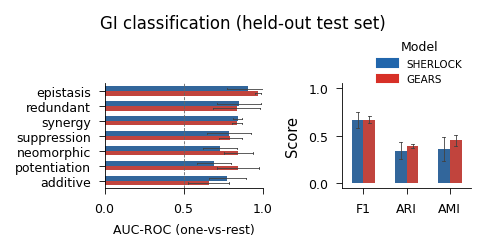

Panel E (test set) saved.


In [27]:
# ── Panel E (test set): GI classification on held-out combos only ────────
# Same layout as Panel E above, but scored on the held-out test combos.
MODEL_ORDER = ['SHERLOCK', 'GEARS']
class_order_test = (
    class_df_ci_test.groupby('class')['auc_roc']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
bar_pal = {'SHERLOCK': CLR_SHERLOCK, 'GEARS': CLR_GEARS}

TEXT_SCALE_E = -1.0  # +/- pt added to all Panel E text uniformly; 0.0 == RC defaults

fig_et, (ax_et1, ax_et2) = plt.subplots(
    1, 2, figsize=(300/PPI, 150/PPI), constrained_layout=True,
    gridspec_kw={'width_ratios': [2.2, 1.8]},
)

# Left: per-class AUC-ROC (test set)
sns.barplot(
    data=class_df_ci_test.dropna(subset=['auc_roc']),
    y='class', x='auc_roc',
    hue='model', hue_order=MODEL_ORDER,
    palette=bar_pal, order=class_order_test,
    width=0.62, errorbar='sd', capsize=0.15, err_kws={'linewidth': 0.4}, ax=ax_et1, legend=False,
)
ax_et1.axvline(0.5, color='0.4', linewidth=0.4, linestyle='--')
ax_et1.set_xlabel('AUC-ROC (one-vs-rest)', fontsize=mpl.rcParams['axes.labelsize'] + TEXT_SCALE_E - 1)
ax_et1.set_ylabel('')
ax_et1.set_yticklabels([_CLASS_LABEL_MAP.get(c, c) for c in class_order_test])
ax_et1.set_xlim(0, 1)
ax_et1.set_xticks([0, 0.5, 1.0])
ax_et1.tick_params(axis='x', labelsize=mpl.rcParams['xtick.labelsize'] + TEXT_SCALE_E)
ax_et1.tick_params(axis='y', labelsize=mpl.rcParams['ytick.labelsize'] + TEXT_SCALE_E)
ax_et1.spines['left'].set_linewidth(0.4)
ax_et1.spines['bottom'].set_linewidth(0.4)
ax_et1.tick_params(axis='both', width=0.4)
ax_et1.spines['top'].set_visible(False)
ax_et1.spines['right'].set_visible(False)
h1 = [Patch(color=bar_pal[m], label=m) for m in MODEL_ORDER]
l1 = list(MODEL_ORDER)

# Right: F1, ARI, AMI with CIs across runs (test set)
sns.barplot(
    data=summ_long_ci_test, x='Metric', y='score',
    hue='model', hue_order=MODEL_ORDER,
    palette=bar_pal, width=0.55, errorbar='sd', capsize=0.15, err_kws={'linewidth': 0.4}, ax=ax_et2,
)
ax_et2.set_xlabel('')
ax_et2.set_ylabel('Score', fontsize=mpl.rcParams['axes.labelsize'] + TEXT_SCALE_E)
ax_et2.set_ylim(-0.05, 1.05)
ax_et2.tick_params(axis='x', labelsize=mpl.rcParams['xtick.labelsize'] + TEXT_SCALE_E)
ax_et2.tick_params(axis='y', labelsize=mpl.rcParams['ytick.labelsize'] + TEXT_SCALE_E)
ax_et2.spines['left'].set_linewidth(0.4)
ax_et2.spines['bottom'].set_linewidth(0.4)
ax_et2.tick_params(axis='both', width=0.4)
ax_et2.spines['top'].set_visible(False)
ax_et2.spines['right'].set_visible(False)
ax_et2.get_legend().remove()
ax_et2.legend(h1, l1, title='Model', frameon=False,
              fontsize=mpl.rcParams['legend.fontsize'] + TEXT_SCALE_E,
              title_fontsize=mpl.rcParams['legend.title_fontsize'] + TEXT_SCALE_E,
              loc='upper right', bbox_to_anchor=(1, 1.5))

fig_et.suptitle('GI classification (held-out test set)',
                fontsize=mpl.rcParams['axes.titlesize'] + TEXT_SCALE_E)
fig_et.savefig(OUT_DIR / 'panel_e_gi_classification_test.svg')
plt.show()
print('Panel E (test set) saved.')

/var/tmp/ipykernel_1076777/1243344613.py:69: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig_f.savefig(OUT_DIR / 'panel_f_gi_heatmap.svg')
/home/sc5625/.local/share/mamba/envs/sherlock/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


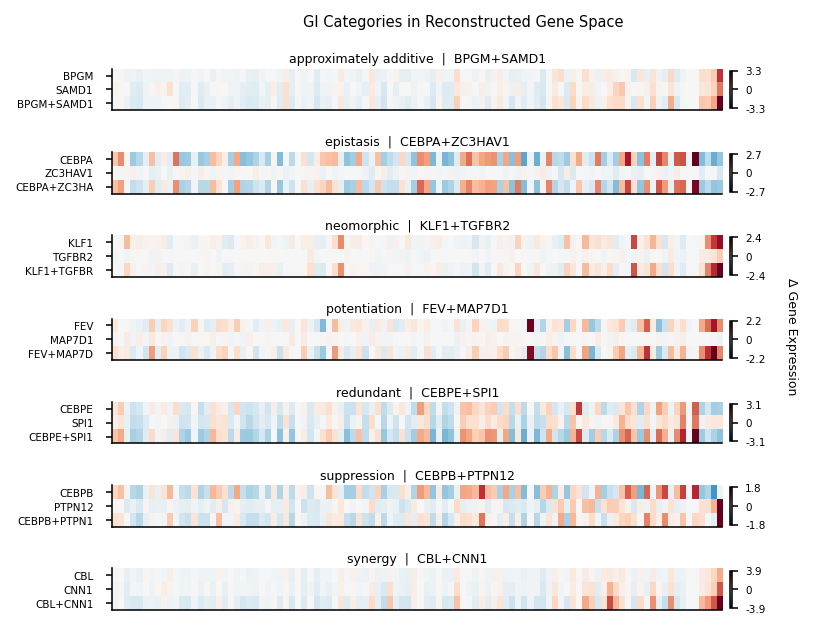

Panel F saved. Arrow pairs: ['CBL/CNN1', 'BPGM/SAMD1', 'CEBPA/ZC3HA', 'KLF1/TGFBR', 'FEV/MAP7D', 'CEBPE/SPI1', 'CEBPB/PTPN1']


In [28]:
# ── Panel F: GI Categories in Gene Space ─────────────────────────────────
# One correctly-classified example per GT category (prefer held-out).
# Gene pool: top 100 by variance across all perturbations in treat_effect.
# Also captures _gi_examples for use as panel D arrow annotations.

def _ch(s):
    parts = str(s).split('+', 1)
    return '+'.join(sorted(p.strip() for p in parts)) if len(parts) == 2 else str(s)

_te_f = data.uns['treat_effect'].to_df()
_te_f.index = _te_f.index.map(_ch)

def _eff_f(pert):
    k = _ch(pert)
    return _te_f.loc[k].values if k in _te_f.index else None

# Top-100 highest-variance genes across all perturbations
_hv100 = np.argsort(_te_f.var(axis=0).values)[-100:]

_cats_f = _cats_gi   # defined alongside _gi_examples in the synergy UMAP cell

_nf       = len(_gi_examples)
TEXT_SCALE_F = -2.0  # +/- pt added to all Panel F text uniformly; 0.0 == RC defaults
fig_f, _axes_f_col = plt.subplots(
    _nf, 1, figsize=(600/PPI, 450/PPI), constrained_layout=True,
    gridspec_kw={'hspace': 1.0},
)
_axes_f_flat = np.array(_axes_f_col).flatten()
fig_f.get_layout_engine().set(h_pad=0.2)

for _i, _cat in enumerate(_cats_f):
    _ax = _axes_f_flat[_i]
    if _cat not in _gi_examples:
        _ax.set_visible(False)
        continue

    _row        = _gi_examples[_cat]
    _na, _nb    = str(_row['pert_a']), str(_row['pert_b'])
    _combo      = _ch(f'{_na}+{_nb}')
    _A, _B, _AB = _eff_f(_na), _eff_f(_nb), _eff_f(_combo)

    if _A is None or _B is None or _AB is None:
        _ax.text(0.5, 0.5, f'missing data\n{_combo}', ha='center', va='center',
                 transform=_ax.transAxes, fontsize=7 + TEXT_SCALE_F)
        continue

    _mat  = np.stack([_A[_hv100], _B[_hv100], _AB[_hv100]])
    _vabs = float(np.abs(_mat).max()) or 1.0
    _im   = _ax.imshow(_mat, aspect='auto', cmap='RdBu_r',
                       vmin=-_vabs, vmax=_vabs, interpolation='nearest')
    _cbar = plt.colorbar(_im, ax=_ax, shrink=0.9, pad=0.01)
    _cbar.ax.tick_params(labelsize=mpl.rcParams['ytick.labelsize'] + TEXT_SCALE_F)
    _cbar.set_ticks([-_vabs, 0, _vabs])
    _cbar.set_ticklabels([f'{-_vabs:.1f}', '0', f'{_vabs:.1f}'])

    _ax.set_yticks([0, 1, 2])
    _ax.set_yticklabels([_na, _nb, f'{_na[:5]}+{_nb[:5]}'], fontsize=7 + TEXT_SCALE_F)
    _ax.tick_params(axis='y', pad=6)
    _ax.set_xticks([])
    _ax.set_title(f'{_cat}  |  {_combo}', pad=3,
                   fontsize=mpl.rcParams['axes.titlesize'] + TEXT_SCALE_F - 1)



fig_f.text(0.85, 0.5, 'Δ Gene Expression', rotation=270, va='center', ha='center',
           fontsize=mpl.rcParams['axes.labelsize'] + TEXT_SCALE_F)
fig_f.suptitle('GI Categories in Reconstructed Gene Space',
                fontsize=mpl.rcParams['axes.titlesize'] + TEXT_SCALE_F)
fig_f.savefig(OUT_DIR / 'panel_f_gi_heatmap.svg')
plt.show()

# Build arrow dict for panel D
_gi_arrows = {}
for _cat, _row in _gi_examples.items():
    _na2, _nb2 = str(_row['pert_a']), str(_row['pert_b'])
    _cidx = _ch(f'{_na2}+{_nb2}')
    if _cidx in syn_umap.index:
        _lbl = f'{_na2[:5]}/{_nb2[:5]}'
        _gi_arrows[_lbl] = _cidx

print(f'Panel F saved. Arrow pairs: {list(_gi_arrows.keys())}')

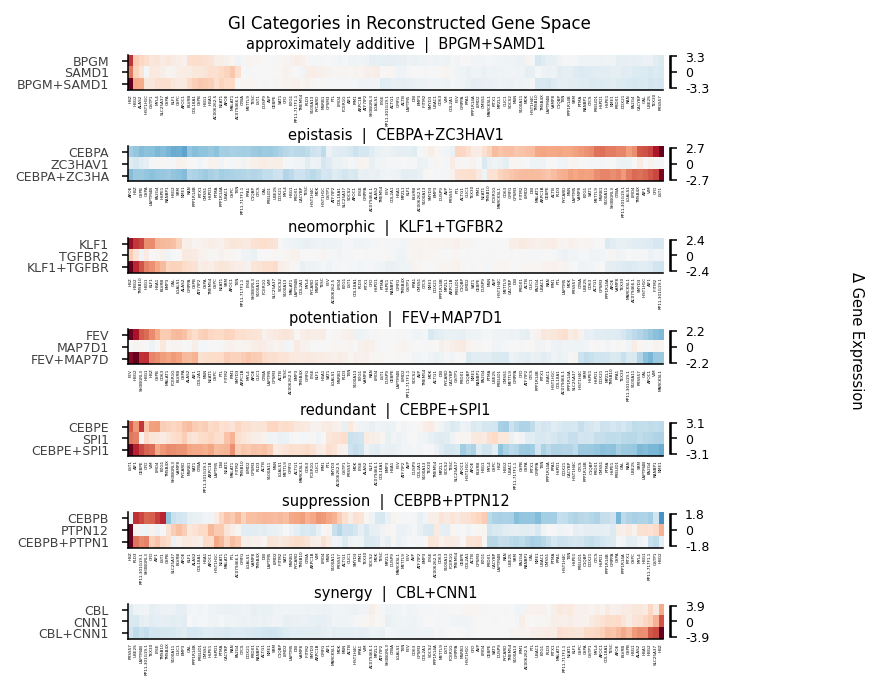

Panel F saved. Arrow pairs: ['CBL/CNN1', 'BPGM/SAMD1', 'CEBPA/ZC3HA', 'KLF1/TGFBR', 'FEV/MAP7D', 'CEBPE/SPI1', 'CEBPB/PTPN1']


In [29]:
# ── Panel F: GI Categories in Gene Space ─────────────────────────────────
# One correctly-classified example per GT category (prefer held-out).
# Gene pool: top 100 by variance across all perturbations in treat_effect.
# Genes are hierarchically clustered within each example; no dendrogram shown.
# Also captures _gi_examples for use as panel D arrow annotations.

from scipy.cluster.hierarchy import linkage, leaves_list

def _ch(s):
    parts = str(s).split('+', 1)
    return '+'.join(sorted(p.strip() for p in parts)) if len(parts) == 2 else str(s)

_te_f = data.uns['treat_effect'].to_df()
_te_f.index = _te_f.index.map(_ch)

def _eff_f(pert):
    k = _ch(pert)
    return _te_f.loc[k].values if k in _te_f.index else None

# Top-100 highest-variance genes across all perturbations
_hv100 = np.argsort(_te_f.var(axis=0).values)[-100:]
_gene_names_f = _te_f.columns.to_numpy()[_hv100]

_cats_f = _cats_gi   # defined alongside _gi_examples in the synergy UMAP cell

_nf = len(_gi_examples)

TEXT_SCALE_F = -1  # +/- pt added to all Panel F text uniformly; 0.0 == RC defaults
GENE_FONTSIZE_F = 2
TEXT_SCALE_GENES_F = 0.0  # +/- pt on the x-axis gene labels (scale factor)
GENE_WIDTH_F = 0.14  # figure width in inches allocated per displayed gene
ROW_HEIGHT_PX_F = 128  # figure height (px) per subplot row

# Manual layout (not constrained_layout) so the figure saves at exactly the
# specified figsize and the title / row spacing are directly controllable.
SUBPLOT_TOP_F    = 0.93  # smaller gap between the title and the top row
SUBPLOT_BOTTOM_F = 0.05
SUBPLOT_HSPACE_F = 1.6    # vertical spacing between subfigures (axis-height units)
fig_f, _axes_f_col = plt.subplots(
    _nf,
    1,
    figsize=(600/PPI, 425/PPI),
)
fig_f.subplots_adjust(
    top=SUBPLOT_TOP_F, bottom=SUBPLOT_BOTTOM_F,
    left=0.20, right=0.88, hspace=SUBPLOT_HSPACE_F,
)

_axes_f_flat = np.atleast_1d(_axes_f_col).flatten()

for _i, _cat in enumerate(_cats_f):
    _ax = _axes_f_flat[_i]

    if _cat not in _gi_examples:
        _ax.set_visible(False)
        continue

    _row = _gi_examples[_cat]
    _na, _nb = str(_row['pert_a']), str(_row['pert_b'])
    _combo = _ch(f'{_na}+{_nb}')

    _A = _eff_f(_na)
    _B = _eff_f(_nb)
    _AB = _eff_f(_combo)

    if _A is None or _B is None or _AB is None:
        _ax.text(
            0.5,
            0.5,
            f'missing data\n{_combo}',
            ha='center',
            va='center',
            transform=_ax.transAxes,
            fontsize=7 + TEXT_SCALE_F,
        )
        continue

    _mat = np.stack([
        _A[_hv100],
        _B[_hv100],
        _AB[_hv100],
    ])

    # Cluster columns using each gene's profile across A, B, and A+B.
    # Only the resulting order is used; no dendrogram is drawn.
    _linkage = linkage(
        _mat.T,
        method='average',
        metric='euclidean',
        optimal_ordering=True,
    )
    _gene_order = leaves_list(_linkage)

    _mat = _mat[:, _gene_order]
    _ordered_gene_names = _gene_names_f[_gene_order]

    _vabs = float(np.abs(_mat).max()) or 1.0

    _im = _ax.imshow(
        _mat,
        aspect='auto',
        cmap='RdBu_r',
        vmin=-_vabs,
        vmax=_vabs,
        interpolation='nearest',
    )

    _cbar = plt.colorbar(
        _im,
        ax=_ax,
        shrink=0.9,
        pad=0.01,
    )
    _cbar.ax.tick_params(
        labelsize=mpl.rcParams['ytick.labelsize'] + TEXT_SCALE_F
    )
    _cbar.set_ticks([-_vabs, 0, _vabs])
    _cbar.set_ticklabels([
        f'{-_vabs:.1f}',
        '0',
        f'{_vabs:.1f}',
    ])

    _ax.set_yticks([0, 1, 2])
    _ax.set_yticklabels(
        [_na, _nb, f'{_na[:5]}+{_nb[:5]}'],
        fontsize=7 + TEXT_SCALE_F,
        fontweight='normal',
        color='0.25',
    )
    _ax.tick_params(axis='y', pad=6)

    # Display every clustered gene name beneath the heatmap
    _ax.set_xticks(np.arange(len(_ordered_gene_names)))
    _ax.set_xticklabels(
        _ordered_gene_names,
        rotation=90,
        ha='center',
        va='top',
        fontsize=GENE_FONTSIZE_F + TEXT_SCALE_GENES_F,
    )
    _ax.tick_params(
        axis='x',
        which='both',
        length=0,
        pad=2,
    )

    _ax.set_title(
        f'{_cat}  |  {_combo}',
        pad=3,
        fontsize=mpl.rcParams['axes.titlesize'] + TEXT_SCALE_F - 1,
    )

fig_f.text(
    0.985,
    0.5,
    'Δ Gene Expression',
    rotation=270,
    va='center',
    ha='right',
    fontsize=mpl.rcParams['axes.labelsize'] + TEXT_SCALE_F,
)

fig_f.suptitle(
    'GI Categories in Reconstructed Gene Space',
    fontsize=mpl.rcParams['axes.titlesize'] + TEXT_SCALE_F,
    y=0.99,
)

fig_f.savefig(
    OUT_DIR / 'panel_f_gi_heatmap.svg',
)

plt.show()

# Build arrow dict for panel D
_gi_arrows = {}

for _cat, _row in _gi_examples.items():
    _na2 = str(_row['pert_a'])
    _nb2 = str(_row['pert_b'])
    _cidx = _ch(f'{_na2}+{_nb2}')

    if _cidx in syn_umap.index:
        _lbl = f'{_na2[:5]}/{_nb2[:5]}'
        _gi_arrows[_lbl] = _cidx

print(f'Panel F saved. Arrow pairs: {list(_gi_arrows.keys())}')

In [30]:
# ── Summary statistics ────────────────────────────────────────────────────
print('=== ATE across runs ===')
print(runs_df[['run', 'ate_all', 'ate_single', 'ate_combo', 'ate_held']].to_string(index=False))

print(f'\nMean ± SD:')
for col in ['ate_all', 'ate_single', 'ate_combo', 'ate_held']:
    print(f"  {col:15s}  {runs_df[col].mean():.4f} ± {runs_df[col].std():.4f}")

print('\n=== GI classification summary (SHERLOCK vs GEARS) ===')
print(summary_df[['model', 'f1_weighted', 'silhouette', 'ari', 'ami']].to_string(index=False))

=== ATE across runs ===
 run  ate_all  ate_single  ate_combo  ate_held
   1 0.844735    0.800936   0.865132  0.842785
   2 0.850011    0.812964   0.872821  0.831279
   3 0.860547    0.823905   0.881407  0.848893
   4 0.851528    0.812448   0.873870  0.834091
   5 0.854787    0.818141   0.876837  0.834018

Mean ± SD:
  ate_all          0.8523 ± 0.0059
  ate_single       0.8137 ± 0.0085
  ate_combo        0.8740 ± 0.0060
  ate_held         0.8382 ± 0.0074

=== GI classification summary (SHERLOCK vs GEARS) ===
   model  f1_weighted  silhouette      ari      ami
SHERLOCK     0.665476    0.011131 0.436843 0.500265
   GEARS     0.645127    0.041840 0.400314 0.480865


Overall silhouette: 0.0317
GT samples used: 86 in 8 classes

                                  mean   n    std
class                                            
redundant                      -0.1706   8 0.1503
neomorphic                     -0.1590  12 0.2078
potentiation                   -0.1573   6 0.2318
synergy (dissimilar phenotype) -0.0050  13 0.1205
synergy (similar phenotype)     0.0791  11 0.1346
epistasis                       0.1020   9 0.1419
approximately additive          0.1417  15 0.1884
suppression                     0.2581  12 0.1049


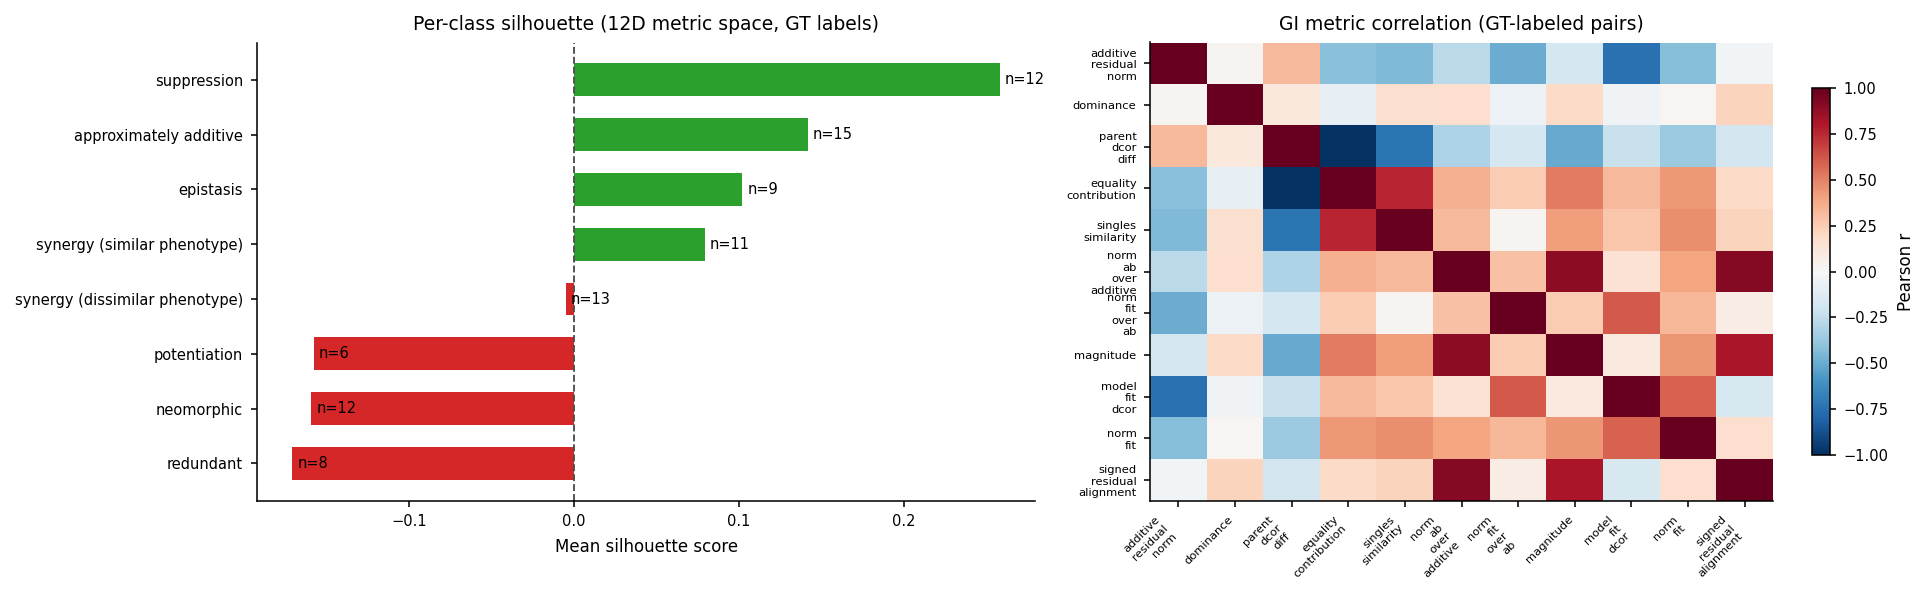

In [31]:
# ── Silhouette investigation ──────────────────────────────────────────────
# Silhouette is computed in the 12D GI metric space (StandardScaled).
# Low overall score can stem from: (1) overlapping classes in metric space,
# (2) small classes making estimation unreliable, (3) correlated metrics
# reducing effective dimensionality without removing redundancy.

from sklearn.metrics import silhouette_samples

# Replicate the _cluster_metrics computation for SHERLOCK
_both  = syn_umap[syn_umap['gt_gi'].notna()].copy()
_avail = [c for c in GI_METRICS if c in _both.columns]
_X_raw = _both[_avail].values.astype(float)
_fin   = np.all(np.isfinite(_X_raw), axis=1)
_both  = _both[_fin].copy()
_X_s   = StandardScaler().fit_transform(_X_raw[_fin])
_y_gt  = _both['gt_gi'].values.astype(str)

# Per-sample silhouette → aggregate per class
_samp_sil = silhouette_samples(_X_s, _y_gt)
_sil_df   = pd.DataFrame({'class': _y_gt, 'silhouette': _samp_sil})
_per_cls  = (_sil_df.groupby('class')['silhouette']
               .agg(mean='mean', n='count', std='std')
               .sort_values('mean'))

print(f"Overall silhouette: {_samp_sil.mean():.4f}")
print(f"GT samples used: {len(_y_gt)} in {len(np.unique(_y_gt))} classes\n")
print(_per_cls.to_string(float_format='{:.4f}'.format))

# Metric pairwise correlation (may reveal redundancy inflating some distances)
_corr = pd.DataFrame(_X_raw[_fin], columns=_avail).corr()

fig_inv, (ax_i1, ax_i2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: per-class mean silhouette
colors = ['#d62728' if v < 0 else '#2ca02c' for v in _per_cls['mean']]
ax_i1.barh(_per_cls.index, _per_cls['mean'], color=colors, height=0.6)
ax_i1.axvline(0, color='0.3', linewidth=0.9, linestyle='--')
for i, (cls, row) in enumerate(_per_cls.iterrows()):
    ax_i1.text(row['mean'] + 0.003, i, f"n={int(row['n'])}", va='center', fontsize=7)
ax_i1.set_xlabel('Mean silhouette score')
ax_i1.set_title('Per-class silhouette (12D metric space, GT labels)')
ax_i1.spines['top'].set_visible(False); ax_i1.spines['right'].set_visible(False)

# Right: metric correlation heatmap — high off-diagonal correlations explain
# why the effective dimensionality is lower than 12
short = [m.replace('_', '\n') for m in _avail]
im = ax_i2.imshow(_corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax_i2.set_xticks(range(len(_avail))); ax_i2.set_xticklabels(short, fontsize=5.5, rotation=45, ha='right')
ax_i2.set_yticks(range(len(_avail))); ax_i2.set_yticklabels(short, fontsize=5.5)
plt.colorbar(im, ax=ax_i2, shrink=0.8, label='Pearson r')
ax_i2.set_title('GI metric correlation (GT-labeled pairs)')

plt.tight_layout()
plt.show()
